# AI Lab Report Notebook
## Comparing SmartSeq and DropSeq gene expression data

In this notebook, I will explore the gene expression datasets from the AI Lab assignment.

The main goals are:
- understand what files are available
- explore the raw and processed data
- compare SmartSeq and DropSeq
- compare MCF7 and HCC1806
- look at data structure using PCA and clustering
- try a simple classifier on the normalized training data

I will keep the analysis simple and clear, since this is more of a test.

## 1. Import the libraries

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

## 2. Set the paths

In [2]:
BASE = Path(r"C:\Users\hugoo\OneDrive\Desktop\ai-lab-report\data")

SMART = BASE / "SmartSeq"
DROP = BASE / "DropSeq"

print("SmartSeq folder exists:", SMART.exists())
print("DropSeq folder exists:", DROP.exists())

SmartSeq folder exists: True
DropSeq folder exists: True


## 3. Check the files inside the folders

In [3]:
print("SMARTSEQ FILES")
for f in sorted(SMART.glob("*")):
    print("-", f.name)

print("\nDROPSEQ FILES")
for f in sorted(DROP.glob("*")):
    print("-", f.name)

SMARTSEQ FILES
- HCC1806_SmartS_Filtered_Data.txt
- HCC1806_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt
- HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt
- HCC1806_SmartS_MetaData.tsv
- HCC1806_SmartS_Unfiltered_Data.txt
- MCF7_SmartS_Filtered_Data.txt
- MCF7_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt
- MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt
- MCF7_SmartS_MetaData.tsv
- MCF7_SmartS_Unfiltered_Data.txt

DROPSEQ FILES
- HCC1806_Filtered_Normalised_3000_Data_test_anonim.txt
- HCC1806_Filtered_Normalised_3000_Data_train.txt
- MCF7_Filtered_Normalised_3000_Data_test_anonim.txt
- MCF7_Filtered_Normalised_3000_Data_train.txt


## 4. Some helper functions

In [4]:
def load_expr(path):
    """
    Load a gene expression matrix where:
    - rows are genes
    - columns are cells/samples
    """
    df = pd.read_csv(path, sep=r"\s+", engine="python", index_col=0)
    
    # remove quotes from gene names and sample names if they exist
    df.index = df.index.astype(str).str.replace('"', '', regex=False)
    df.columns = df.columns.astype(str).str.replace('"', '', regex=False)
    
    return df


def dataset_summary(expr, dataset_name):
    """
    Basic summary of one expression matrix.
    """
    return pd.DataFrame({
        "dataset": [dataset_name],
        "n_genes": [expr.shape[0]],
        "n_samples": [expr.shape[1]],
        "mean_value": [expr.values.mean()],
        "median_value": [np.median(expr.values)],
        "zero_fraction": [(expr.values == 0).mean()]
    })


def sample_qc(expr):
    """
    QC summary per sample/cell.
    """
    total_counts = expr.sum(axis=0)
    detected_genes = (expr > 0).sum(axis=0)
    zero_fraction = (expr == 0).sum(axis=0) / expr.shape[0]
    
    return pd.DataFrame({
        "total_counts": total_counts,
        "detected_genes": detected_genes,
        "zero_fraction": zero_fraction
    })


def gene_qc(expr):
    """
    QC summary per gene.
    """
    mean_expression = expr.mean(axis=1)
    detected_samples = (expr > 0).sum(axis=1)
    zero_fraction = (expr == 0).sum(axis=1) / expr.shape[1]
    
    return pd.DataFrame({
        "mean_expression": mean_expression,
        "detected_samples": detected_samples,
        "zero_fraction": zero_fraction
    })


def plot_hist(series, title, xlabel, bins=40):
    plt.figure(figsize=(7, 4))
    plt.hist(series, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.show()


def pca_plot(expr, labels=None, title="PCA plot"):
    """
    PCA on samples (columns).
    """
    X = expr.T.copy()  # samples x genes
    
    # standardize features
    X_scaled = StandardScaler().fit_transform(X)
    
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(X_scaled)
    
    plot_df = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1]
    }, index=X.index)
    
    plt.figure(figsize=(7, 5))
    
    if labels is None:
        plt.scatter(plot_df["PC1"], plot_df["PC2"], s=25)
    else:
        plot_df["label"] = labels.loc[plot_df.index].values
        sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="label", s=40)
    
    plt.title(title)
    plt.show()
    
    print("Explained variance ratio:", pca.explained_variance_ratio_)


def top_variable_genes(expr, top_n=50):
    """
    Get the most variable genes.
    """
    gene_var = expr.var(axis=1).sort_values(ascending=False)
    return gene_var.head(top_n).index


def heatmap_top_variable_genes(expr, labels=None, top_n=30, title="Top variable genes heatmap"):
    genes = top_variable_genes(expr, top_n=top_n)
    sub = expr.loc[genes]
    
    # standardize each gene for easier visual comparison
    sub_z = sub.sub(sub.mean(axis=1), axis=0).div(sub.std(axis=1).replace(0, 1), axis=0)
    
    plt.figure(figsize=(12, 7))
    sns.heatmap(sub_z, cmap="vlag", center=0)
    plt.title(title)
    plt.xlabel("Samples")
    plt.ylabel("Genes")
    plt.show()

## 5. Load the main datasets

Now I load the files I want to work with.

SmartSeq:
- unfiltered
- filtered
- normalized train
- metadata

DropSeq:
- normalized train

I start with the training files because they already have the real labels and are enough for exploration and simple modeling.

In [5]:
# SMARTSEQ
smart_mcf7_unfiltered = load_expr(SMART / "MCF7_SmartS_Unfiltered_Data.txt")
smart_mcf7_filtered = load_expr(SMART / "MCF7_SmartS_Filtered_Data.txt")
smart_mcf7_norm_train = load_expr(SMART / "MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt")

smart_hcc_unfiltered = load_expr(SMART / "HCC1806_SmartS_Unfiltered_Data.txt")
smart_hcc_filtered = load_expr(SMART / "HCC1806_SmartS_Filtered_Data.txt")
smart_hcc_norm_train = load_expr(SMART / "HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt")

# METADATA
meta_mcf7 = pd.read_csv(SMART / "MCF7_SmartS_MetaData.tsv", sep="\t")
meta_hcc = pd.read_csv(SMART / "HCC1806_SmartS_MetaData.tsv", sep="\t")

# clean metadata filenames
meta_mcf7["Filename"] = meta_mcf7["Filename"].astype(str).str.replace('"', '', regex=False)
meta_hcc["Filename"] = meta_hcc["Filename"].astype(str).str.replace('"', '', regex=False)

# DROPSEQ
drop_mcf7_norm_train = load_expr(DROP / "MCF7_Filtered_Normalised_3000_Data_train.txt")
drop_hcc_norm_train = load_expr(DROP / "HCC1806_Filtered_Normalised_3000_Data_train.txt")

## 6. Quick shape check

Here I just check the size of each dataset.

This tells me:
- how many genes there are
- how many cells/samples there are

In [6]:
datasets = {
    "SmartSeq MCF7 unfiltered": smart_mcf7_unfiltered,
    "SmartSeq MCF7 filtered": smart_mcf7_filtered,
    "SmartSeq MCF7 normalized train": smart_mcf7_norm_train,
    "SmartSeq HCC1806 unfiltered": smart_hcc_unfiltered,
    "SmartSeq HCC1806 filtered": smart_hcc_filtered,
    "SmartSeq HCC1806 normalized train": smart_hcc_norm_train,
    "DropSeq MCF7 normalized train": drop_mcf7_norm_train,
    "DropSeq HCC1806 normalized train": drop_hcc_norm_train,
}

summary_table = pd.concat(
    [dataset_summary(expr, name) for name, expr in datasets.items()],
    ignore_index=True
)

summary_table

,dataset,n_genes,n_samples,mean_value,median_value,zero_fraction
0,SmartSeq MCF7 unfiltered,22934,383,43.368444,0.0,0.602153
1,SmartSeq MCF7 filtered,18945,313,61.114583,1.0,0.471576
2,SmartSeq MCF7 normalized train,3000,250,115.900049,0.0,0.636221
3,SmartSeq HCC1806 unfiltered,23396,243,86.010698,0.0,0.558456
4,SmartSeq HCC1806 filtered,19503,227,107.439569,3.0,0.452056
5,SmartSeq HCC1806 normalized train,3000,182,167.526872,0.0,0.706535
6,DropSeq MCF7 normalized train,3000,21626,0.035819,0.0,0.975294
7,DropSeq HCC1806 normalized train,3000,14682,0.035500,0.0,0.976376


## 7. Look at the SmartSeq metadata

SmartSeq has metadata files, which is very useful.

The metadata tells me things like:
- condition
- cell line
- other sample information

I want to check the columns first so I know what information I can use.

In [7]:
print("MCF7 metadata columns:")
print(meta_mcf7.columns.tolist())
display(meta_mcf7.head())

print("\nHCC1806 metadata columns:")
print(meta_hcc.columns.tolist())
display(meta_hcc.head())

MCF7 metadata columns:
['Filename', 'Cell Line', 'Lane', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']


,Filename,Cell Line,Lane,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
0,output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoo...,MCF7,output.STAR.1,A10,Hypo,72,S28,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
1,output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoo...,MCF7,output.STAR.1,A11,Hypo,72,S29,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
2,output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoo...,MCF7,output.STAR.1,A12,Hypo,72,S30,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
3,output.STAR.1_A1_Norm_S1_Aligned.sortedByCoord...,MCF7,output.STAR.1,A1,Norm,72,S1,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
4,output.STAR.1_A2_Norm_S2_Aligned.sortedByCoord...,MCF7,output.STAR.1,A2,Norm,72,S2,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"



HCC1806 metadata columns:
['Filename', 'Cell Line', 'PCR Plate', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']


,Filename,Cell Line,PCR Plate,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
0,output.STAR.PCRPlate1A10_Normoxia_S123_Aligned...,HCC1806,1,A10,Normo,24,S123,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
1,output.STAR.PCRPlate1A12_Normoxia_S26_Aligned....,HCC1806,1,A12,Normo,24,S26,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
2,output.STAR.PCRPlate1A1_Hypoxia_S97_Aligned.so...,HCC1806,1,A1,Hypo,24,S97,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
3,output.STAR.PCRPlate1A2_Hypoxia_S104_Aligned.s...,HCC1806,1,A2,Hypo,24,S104,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
4,output.STAR.PCRPlate1A3_Hypoxia_S4_Aligned.sor...,HCC1806,1,A3,Hypo,24,S4,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"


## 8. Build the labels I need

For SmartSeq, I get the condition labels from the metadata.

For DropSeq, the condition is written directly inside the column names, so I extract it from there.

This is important because I need labels for:
- PCA coloring
- comparison plots
- classification later

In [8]:
# SMARTSEQ LABELS
smart_mcf7_labels = meta_mcf7.set_index("Filename").loc[smart_mcf7_norm_train.columns, "Condition"]
smart_hcc_labels = meta_hcc.set_index("Filename").loc[smart_hcc_norm_train.columns, "Condition"]

print("SmartSeq MCF7 label counts:")
print(smart_mcf7_labels.value_counts())

print("\nSmartSeq HCC1806 label counts:")
print(smart_hcc_labels.value_counts())

SmartSeq MCF7 label counts:
Condition
Norm    126
Hypo    124
Name: count, dtype: int64

SmartSeq HCC1806 label counts:
Condition
Hypo     97
Normo    85
Name: count, dtype: int64


In [9]:
# DROPSEQ LABELS
def get_dropseq_condition(sample_name):
    if "Normoxia" in sample_name:
        return "Normoxia"
    elif "Hypoxia" in sample_name:
        return "Hypoxia"
    else:
        return "Unknown"

drop_mcf7_labels = pd.Series(
    [get_dropseq_condition(c) for c in drop_mcf7_norm_train.columns],
    index=drop_mcf7_norm_train.columns,
    name="Condition"
)

drop_hcc_labels = pd.Series(
    [get_dropseq_condition(c) for c in drop_hcc_norm_train.columns],
    index=drop_hcc_norm_train.columns,
    name="Condition"
)

print("DropSeq MCF7 label counts:")
print(drop_mcf7_labels.value_counts())

print("\nDropSeq HCC1806 label counts:")
print(drop_hcc_labels.value_counts())

DropSeq MCF7 label counts:
Condition
Normoxia    12705
Hypoxia      8921
Name: count, dtype: int64

DropSeq HCC1806 label counts:
Condition
Hypoxia     8899
Normoxia    5783
Name: count, dtype: int64


## 9. First look at the raw SmartSeq data

The course instructions say it is a good idea to start with the unfiltered data so I can see the issues in the raw dataset before preprocessing.

In [10]:
qc_mcf7_unf = sample_qc(smart_mcf7_unfiltered)
qc_hcc_unf = sample_qc(smart_hcc_unfiltered)

display(qc_mcf7_unf.describe())
display(qc_hcc_unf.describe())

,total_counts,detected_genes,zero_fraction
count,3.830000e+02,383.000000,383.000000
mean,9.946119e+05,9124.219321,0.602153
std,5.503732e+05,2693.309249,0.117437
min,1.000000e+00,1.000000,0.454129
25%,5.987505e+05,8456.500000,0.529563
50%,1.129334e+06,9907.000000,0.568021
75%,1.408638e+06,10789.000000,0.631268
max,2.308057e+06,12519.000000,0.999956


,total_counts,detected_genes,zero_fraction
count,2.430000e+02,243.000000,243.000000
mean,2.012306e+06,10330.358025,0.558456
std,1.171858e+06,2260.259356,0.096609
min,1.140000e+02,35.000000,0.402206
25%,9.910625e+05,10117.000000,0.512353
50%,2.067645e+06,10831.000000,0.537058
75%,2.925182e+06,11409.000000,0.567576
max,5.758132e+06,13986.000000,0.998504


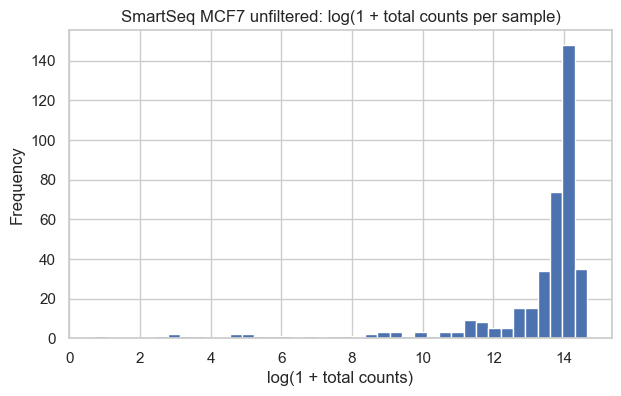

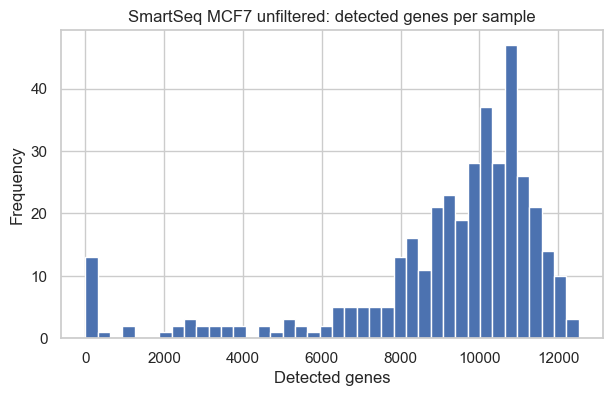

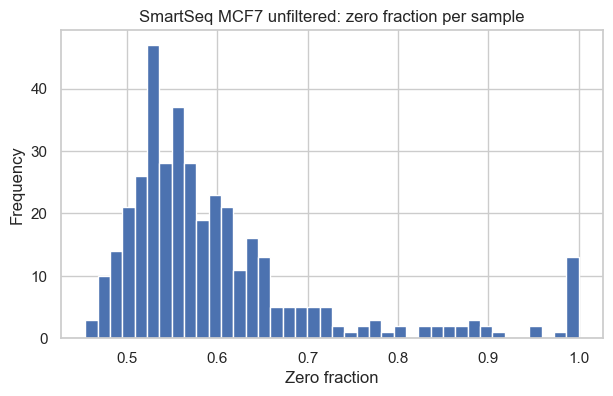

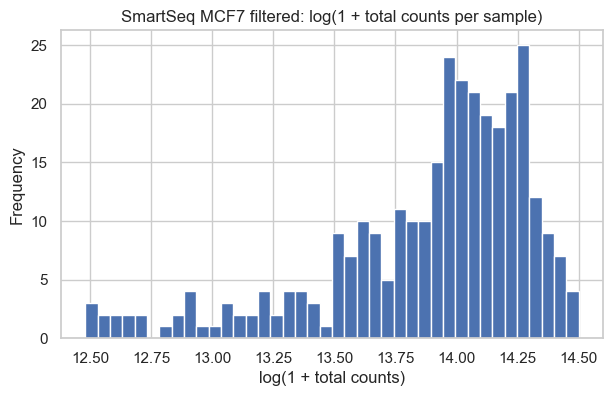

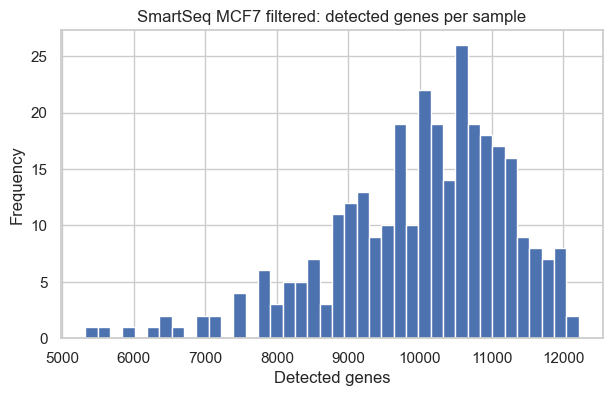

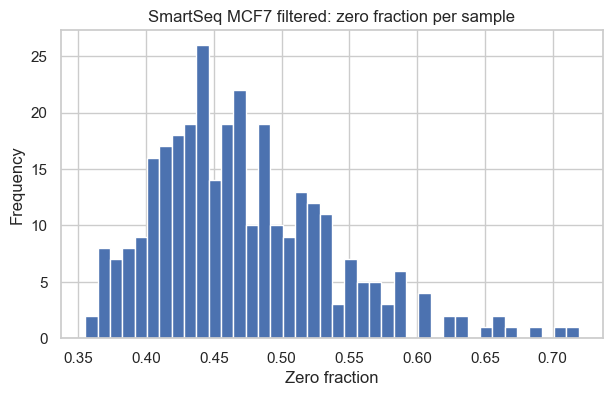

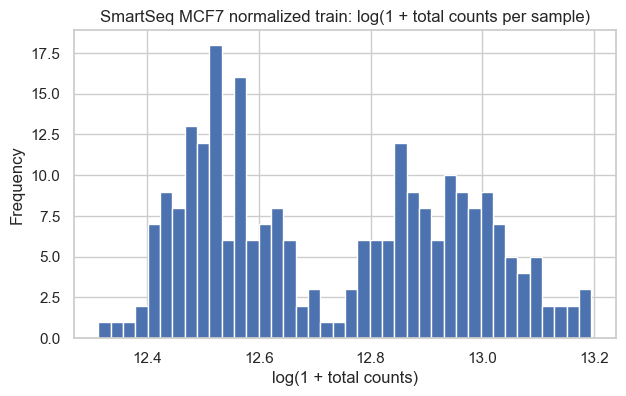

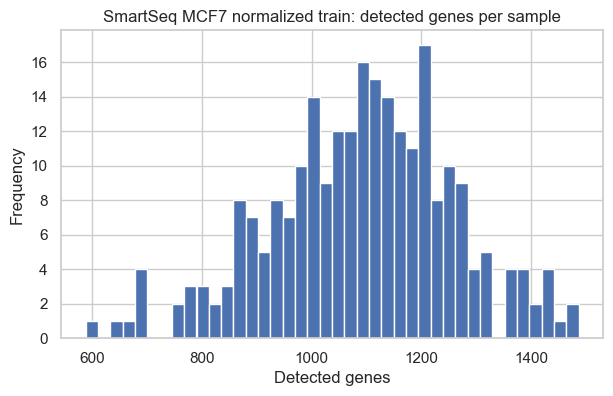

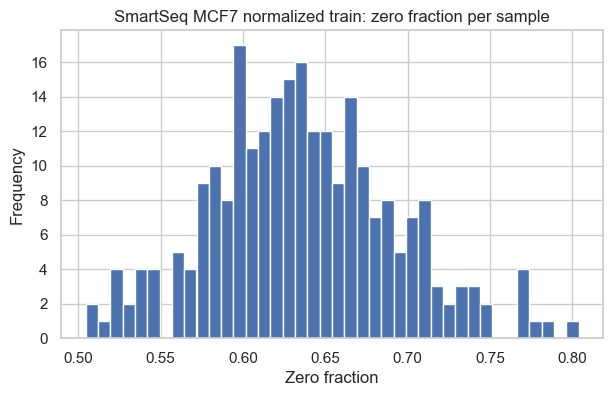

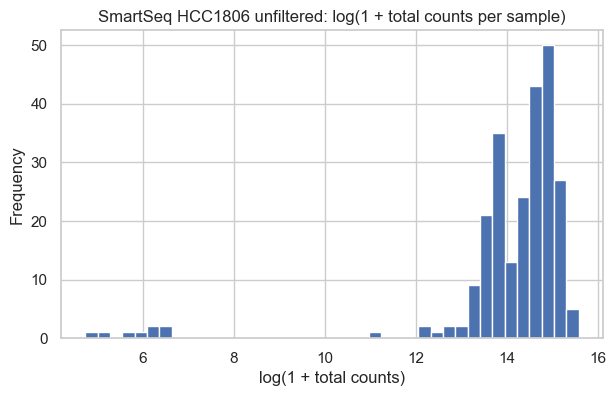

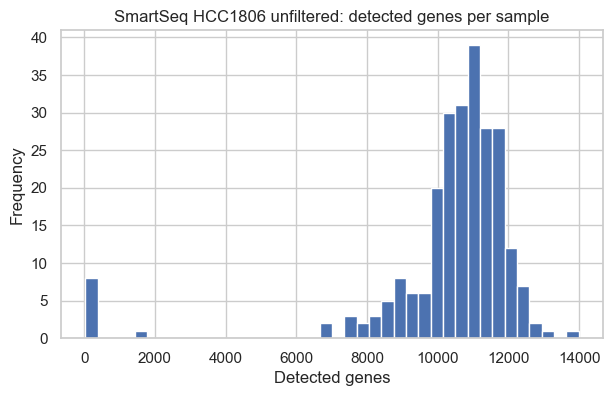

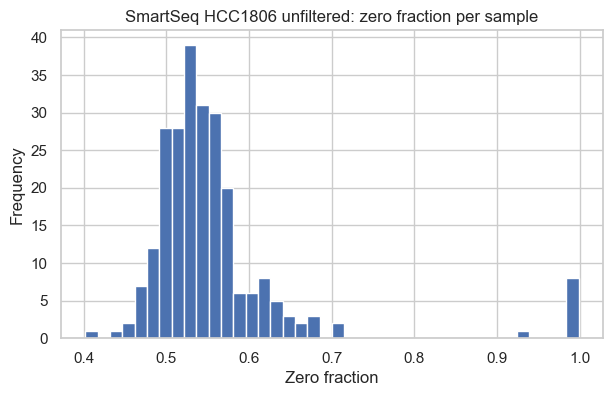

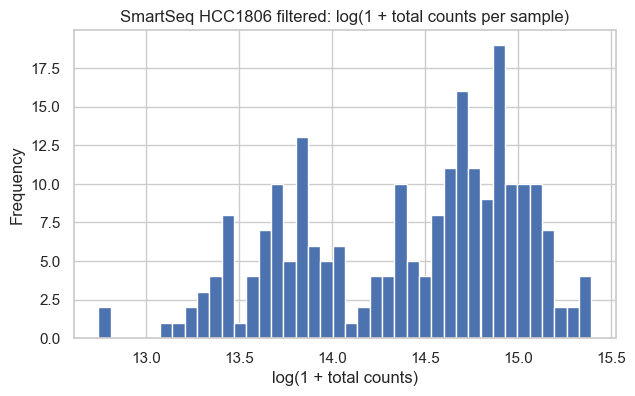

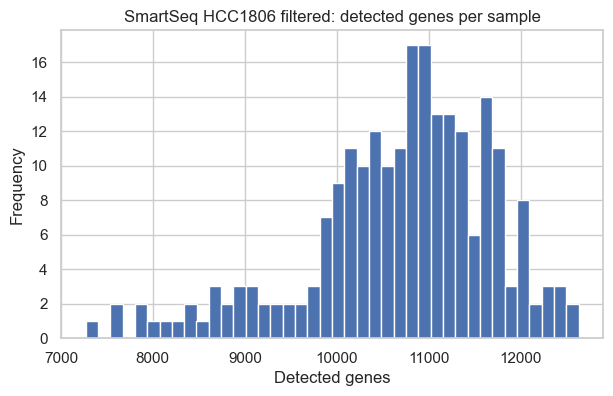

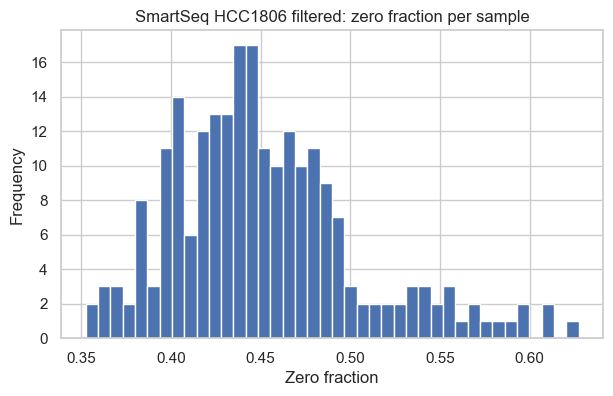

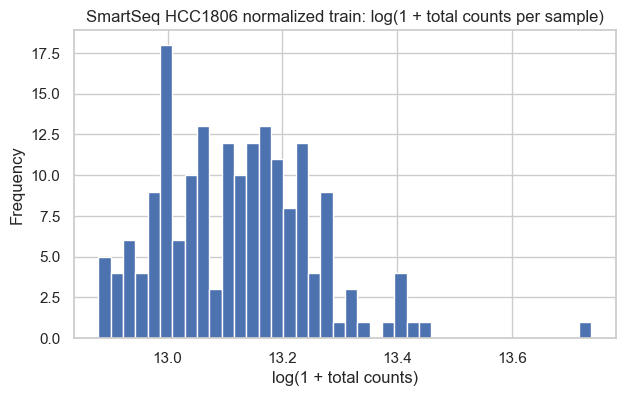

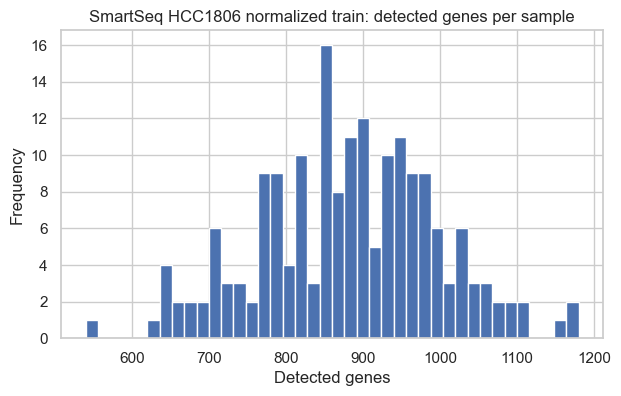

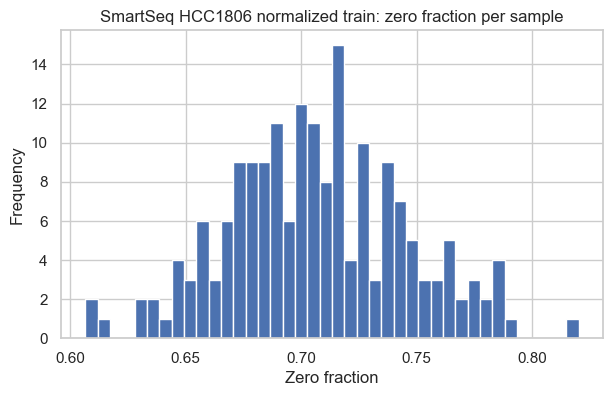

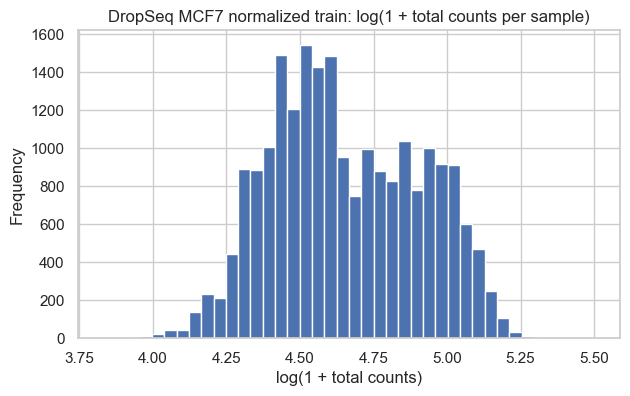

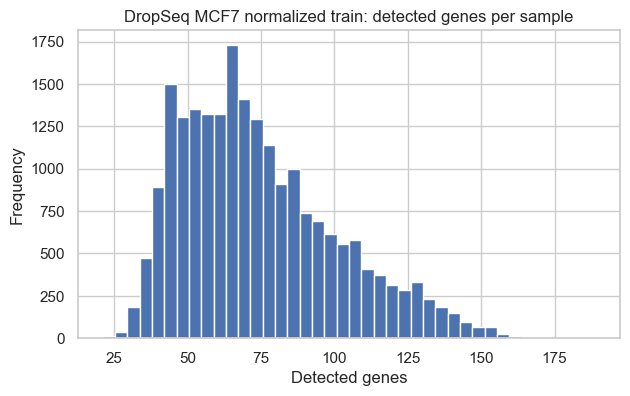

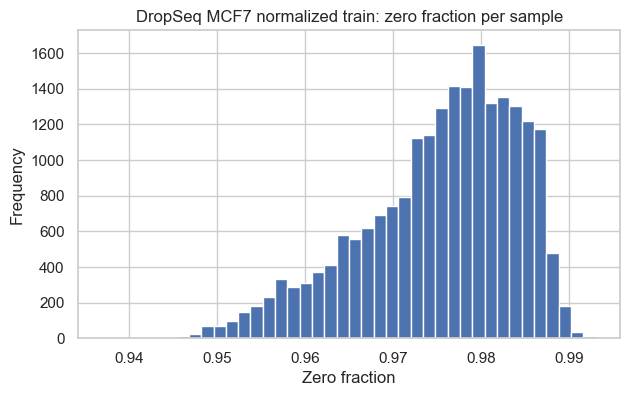

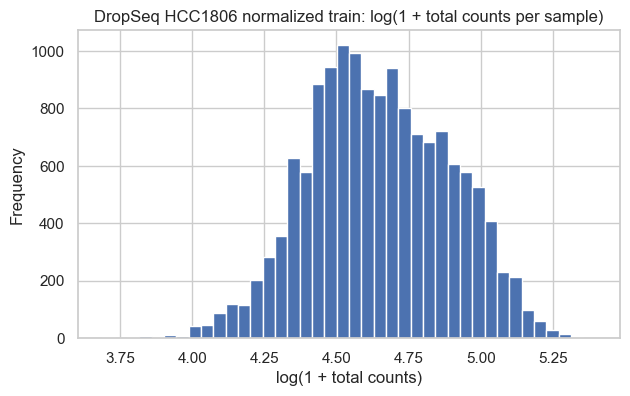

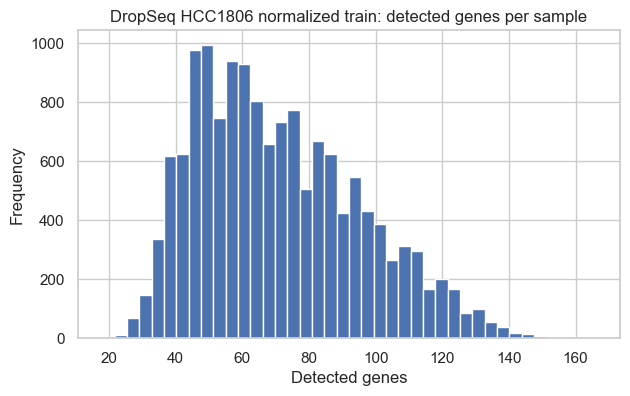

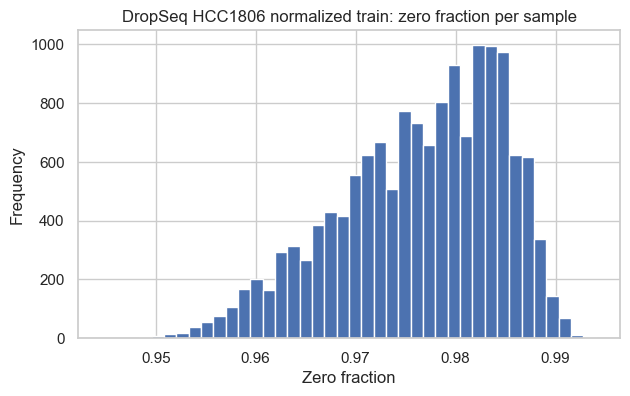

In [11]:
# QC plots for every expression dataset in the notebook.
# This replaces the earlier MCF7-only/HCC-only split so that the same graph family is produced for each dataset.
qc_by_dataset = {name: sample_qc(expr) for name, expr in datasets.items()}

for dataset_name, qc in qc_by_dataset.items():
    plot_hist(
        np.log1p(qc["total_counts"]),
        f"{dataset_name}: log(1 + total counts per sample)",
        "log(1 + total counts)"
    )
    plot_hist(
        qc["detected_genes"],
        f"{dataset_name}: detected genes per sample",
        "Detected genes"
    )
    plot_hist(
        qc["zero_fraction"],
        f"{dataset_name}: zero fraction per sample",
        "Zero fraction"
    )


The QC plotting cell above now creates the same three QC histograms for every dataset loaded in the notebook, instead of only plotting one cell line at a time.


## 10. Quick interpretation of the raw data

The unfiltered SmartSeq data already shows some important issues in the raw gene expression matrices. First, there is a large amount of variation between cells in terms of total counts and number of detected genes. For example, in the MCF7 unfiltered dataset the average number of detected genes per cell is around 9,124, while in HCC1806 it is around 10,330. The total counts also vary a lot across cells, with some cells having extremely low counts and others having very high counts.

Another important point is the high fraction of zero values. The average zero fraction is about 0.60 in MCF7 and about 0.56 in HCC1806, which means that a large part of the matrix is sparse. This is expected in single-cell RNA sequencing data, but it also shows that the raw data contains a lot of noise and many genes are not detected in every cell.

Overall, these results suggest that the raw data is highly heterogeneous and sparse. This helps explain why filtering and normalization are necessary before doing more advanced analyses such as PCA, clustering, or classification.

## 11. Compare unfiltered and filtered SmartSeq data

In [12]:
compare_preprocessing = pd.concat([
    dataset_summary(smart_mcf7_unfiltered, "MCF7 unfiltered"),
    dataset_summary(smart_mcf7_filtered, "MCF7 filtered"),
    dataset_summary(smart_hcc_unfiltered, "HCC1806 unfiltered"),
    dataset_summary(smart_hcc_filtered, "HCC1806 filtered"),
], ignore_index=True)

compare_preprocessing

,dataset,n_genes,n_samples,mean_value,median_value,zero_fraction
0,MCF7 unfiltered,22934,383,43.368444,0.0,0.602153
1,MCF7 filtered,18945,313,61.114583,1.0,0.471576
2,HCC1806 unfiltered,23396,243,86.010698,0.0,0.558456
3,HCC1806 filtered,19503,227,107.439569,3.0,0.452056


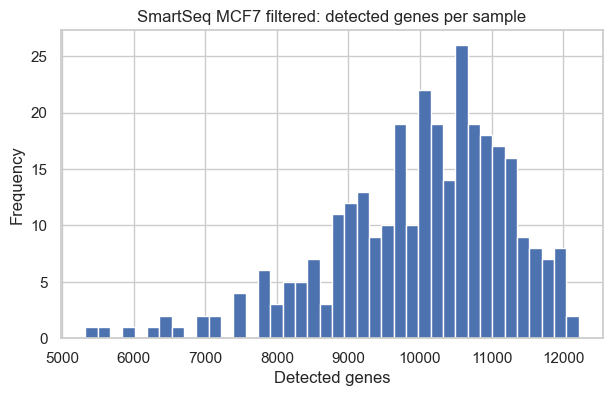

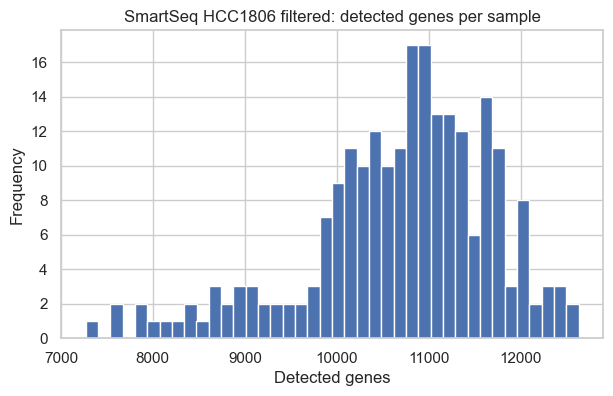

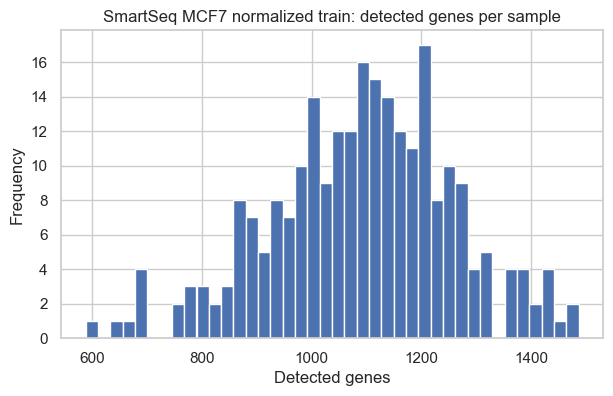

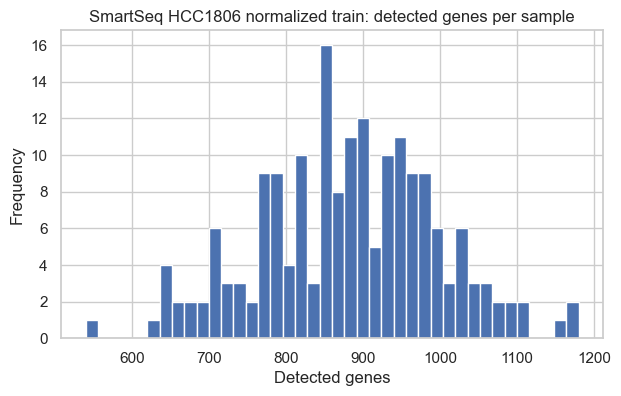

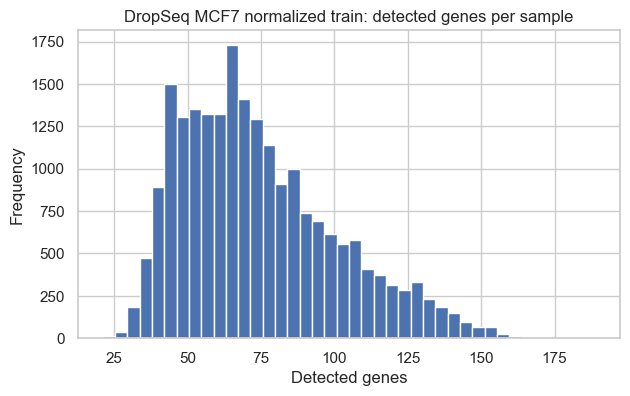

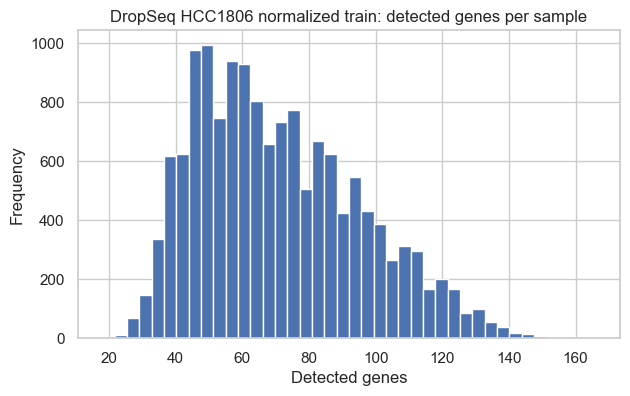

In [13]:
# Filtered-data QC comparison for every filtered expression matrix.
filtered_datasets = {
    "SmartSeq MCF7 filtered": smart_mcf7_filtered,
    "SmartSeq HCC1806 filtered": smart_hcc_filtered,
    "SmartSeq MCF7 normalized train": smart_mcf7_norm_train,
    "SmartSeq HCC1806 normalized train": smart_hcc_norm_train,
    "DropSeq MCF7 normalized train": drop_mcf7_norm_train,
    "DropSeq HCC1806 normalized train": drop_hcc_norm_train,
}

for dataset_name, expr in filtered_datasets.items():
    qc = sample_qc(expr)
    plot_hist(
        qc["detected_genes"],
        f"{dataset_name}: detected genes per sample",
        "Detected genes"
    )


## 12. What filtering seems to do

Comparing the unfiltered and filtered SmartSeq datasets shows that filtering makes the data cleaner and easier to work with. In both cell lines, the number of genes decreases after filtering, which means low-information or rarely detected genes are being removed. At the same time, the median expression value increases from 0 in the unfiltered data to 1 in MCF7 and 3 in HCC1806 after filtering.

Filtering also reduces sparsity. In MCF7, the zero fraction goes from about 0.60 in the unfiltered data to about 0.47 in the filtered data. In HCC1806, it goes from about 0.56 to about 0.45. This means the filtered data contains fewer empty entries and relatively more informative signal.

So, filtering seems to remove part of the noise while keeping the stronger expression patterns. This is useful because it makes the downstream analyses more stable and allows the biological differences between cells to be seen more clearly.

## 13. PCA on normalized SmartSeq data

Now I move to the normalized training data.

This is a better place to look at PCA because normalization reduces some of the technical differences caused by uneven sequencing depth.

I color the PCA plots by condition so I can see whether hypoxia and normoxia separate.

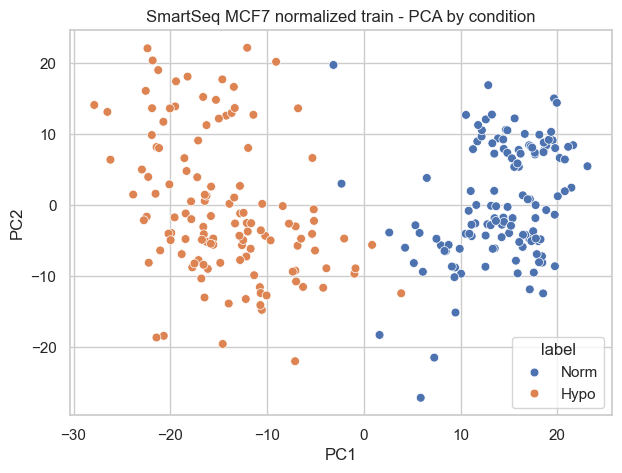

Explained variance ratio: [0.07810178 0.02779398]


In [14]:
pca_plot(
    smart_mcf7_norm_train,
    labels=smart_mcf7_labels,
    title="SmartSeq MCF7 normalized train - PCA by condition"
)

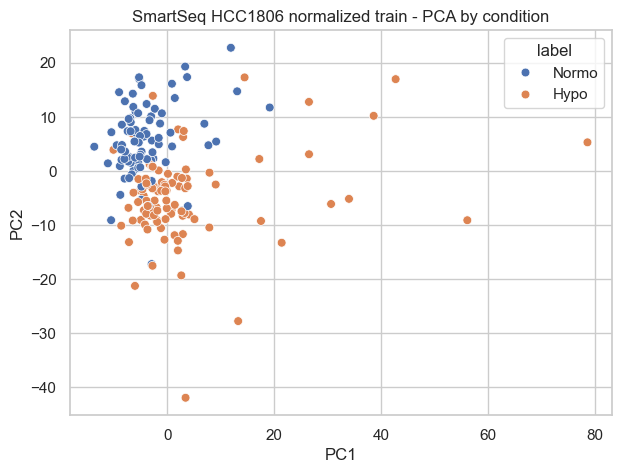

Explained variance ratio: [0.04164704 0.02771966]


In [15]:
pca_plot(
    smart_hcc_norm_train,
    labels=smart_hcc_labels,
    title="SmartSeq HCC1806 normalized train - PCA by condition"
)

## 14. PCA on normalized DropSeq data

Now I do the same thing for DropSeq.

This lets me compare whether the same biological signal is visible in both technologies.

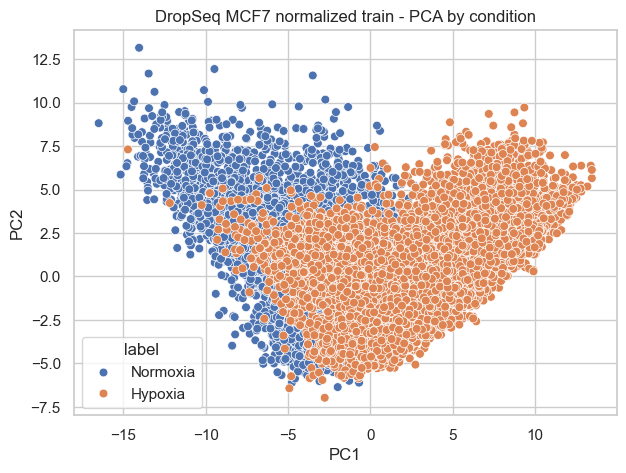

Explained variance ratio: [0.00674412 0.00249983]


In [16]:
pca_plot(
    drop_mcf7_norm_train,
    labels=drop_mcf7_labels,
    title="DropSeq MCF7 normalized train - PCA by condition"
)

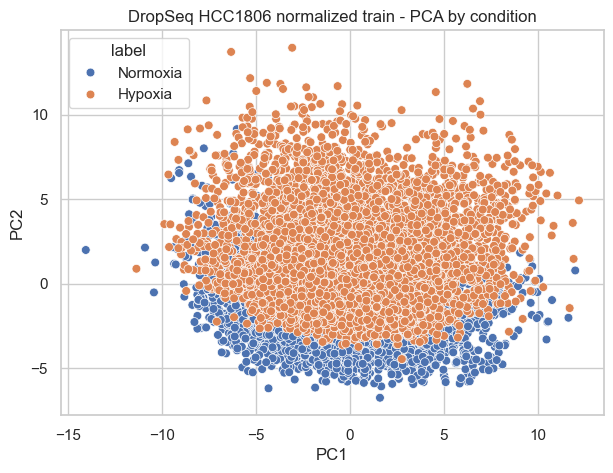

Explained variance ratio: [0.00357671 0.00223465]


In [17]:
pca_plot(
    drop_hcc_norm_train,
    labels=drop_hcc_labels,
    title="DropSeq HCC1806 normalized train - PCA by condition"
)

## 15. PCA interpretation

The PCA plots on the normalized datasets show that the structure of the data is not equally strong across all experiments. In the SmartSeq datasets, the first principal component explains more variation than in the DropSeq datasets. For example, PC1 explains about 7.8% of the variance in SmartSeq MCF7 and about 4.2% in SmartSeq HCC1806, while in DropSeq MCF7 and HCC1806 it explains only about 0.7% and 0.4%, respectively.

This suggests that the SmartSeq data has a stronger visible global structure in the first two principal components, while the DropSeq data is more spread out and less clearly separated in low-dimensional space. A possible reason is that DropSeq contains many more cells and may capture a more complex and diffuse structure, while SmartSeq may produce cleaner separation in the first few components.

Overall, PCA suggests that condition-related structure is present, but its visibility depends on the technology and dataset. In some cases the separation appears stronger, while in others the groups are more mixed, which means that the biological signal may be more subtle or distributed across many dimensions rather than being concentrated in just the first two PCs.

## 16. Heatmaps of the most variable genes

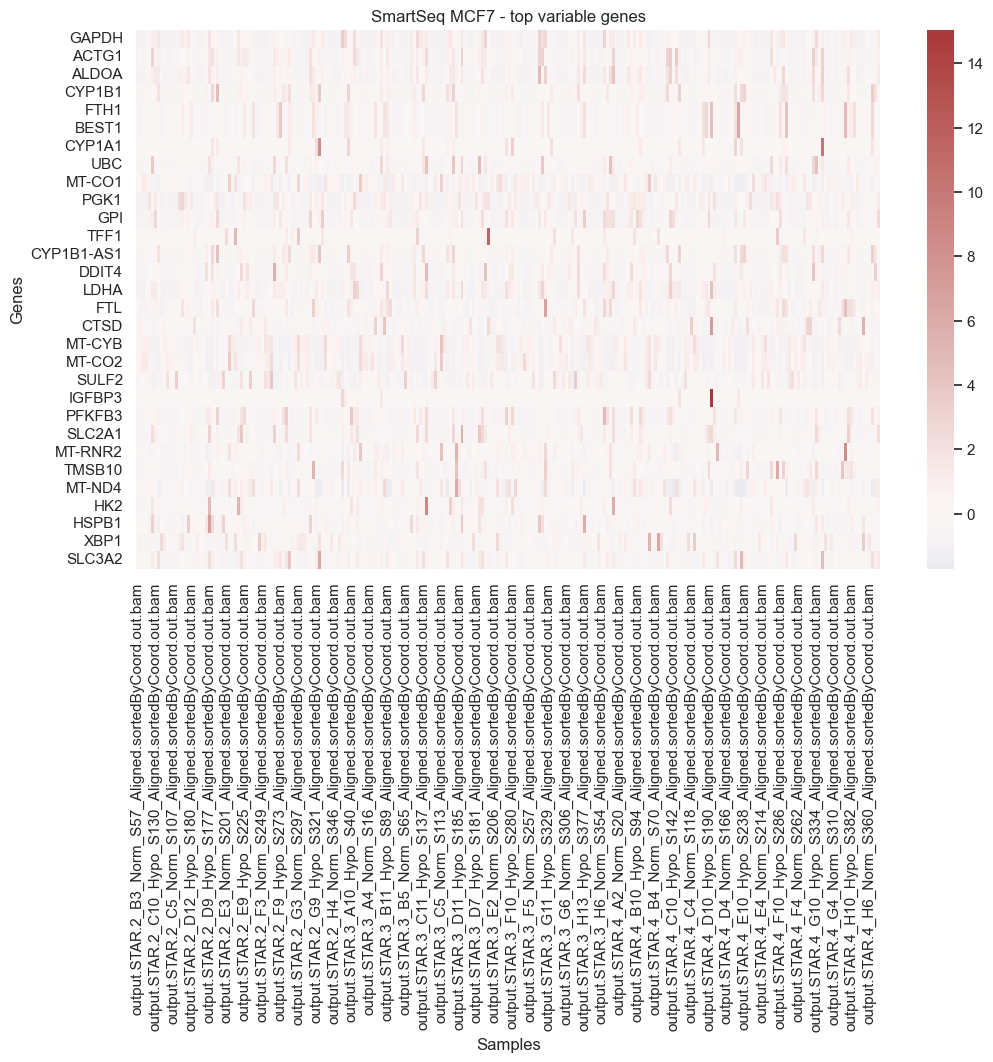

In [18]:
heatmap_top_variable_genes(
    smart_mcf7_norm_train,
    labels=smart_mcf7_labels,
    top_n=30,
    title="SmartSeq MCF7 - top variable genes"
)

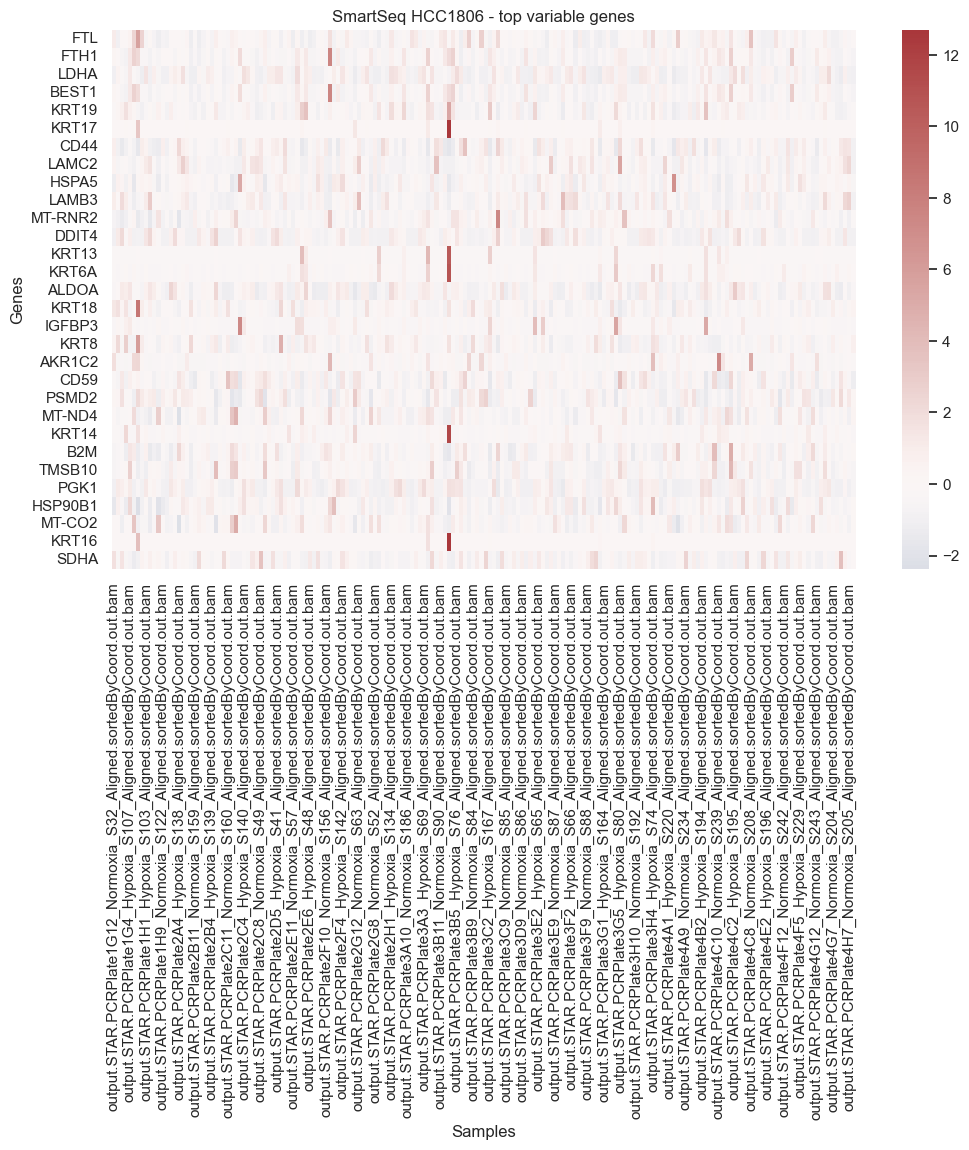

In [19]:
heatmap_top_variable_genes(
    smart_hcc_norm_train,
    labels=smart_hcc_labels,
    top_n=30,
    title="SmartSeq HCC1806 - top variable genes"
)

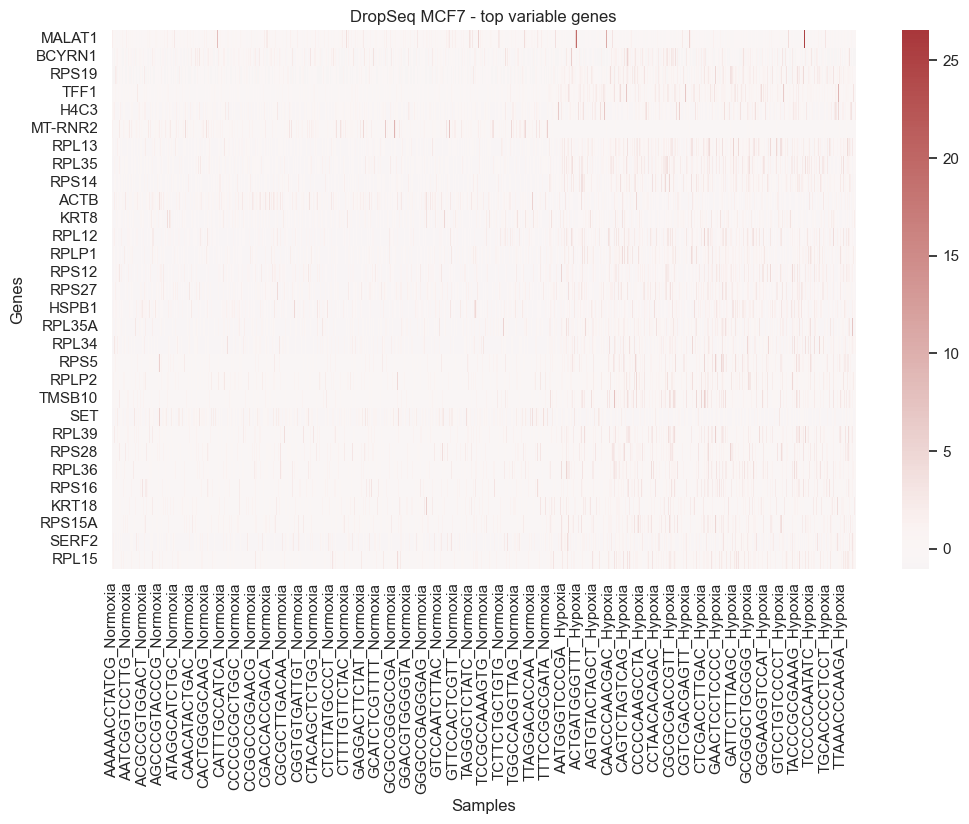

In [20]:
heatmap_top_variable_genes(
    drop_mcf7_norm_train,
    labels=drop_mcf7_labels,
    top_n=30,
    title="DropSeq MCF7 - top variable genes"
)

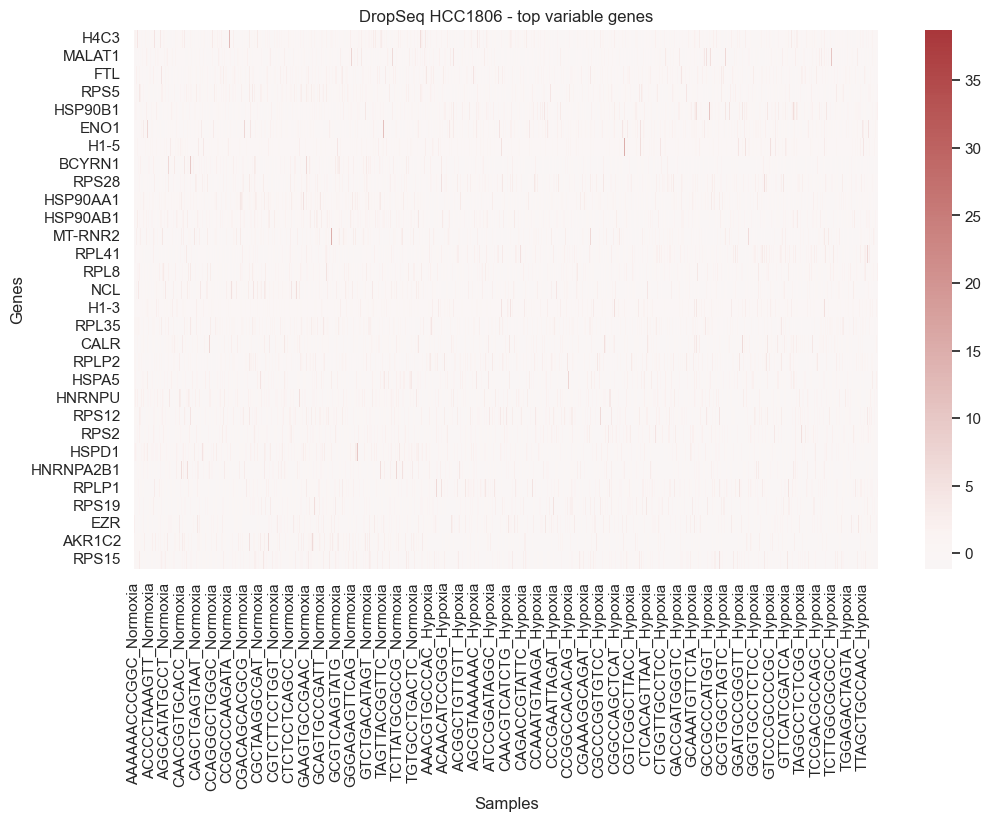

In [21]:
heatmap_top_variable_genes(
    drop_hcc_norm_train,
    labels=drop_hcc_labels,
    top_n=30,
    title="DropSeq HCC1806 - top variable genes"
)

## 17. Compare SmartSeq and DropSeq directly

Now I do one of the most interesting parts of the report.

I compare SmartSeq and DropSeq for the same cell line using the shared genes.

This helps answer:
- do the two technologies produce similar biological structure?
- or does the platform itself create a strong difference?

In [22]:
# MCF7 technology comparison
common_genes_mcf7 = smart_mcf7_norm_train.index.intersection(drop_mcf7_norm_train.index)

mcf7_combined = pd.concat([
    smart_mcf7_norm_train.loc[common_genes_mcf7],
    drop_mcf7_norm_train.loc[common_genes_mcf7]
], axis=1)

mcf7_tech_labels = pd.Series(
    ["SmartSeq"] * smart_mcf7_norm_train.shape[1] + ["DropSeq"] * drop_mcf7_norm_train.shape[1],
    index=mcf7_combined.columns
)

mcf7_cond_labels = pd.concat([smart_mcf7_labels, drop_mcf7_labels])

print(mcf7_combined.shape)

(496, 21876)


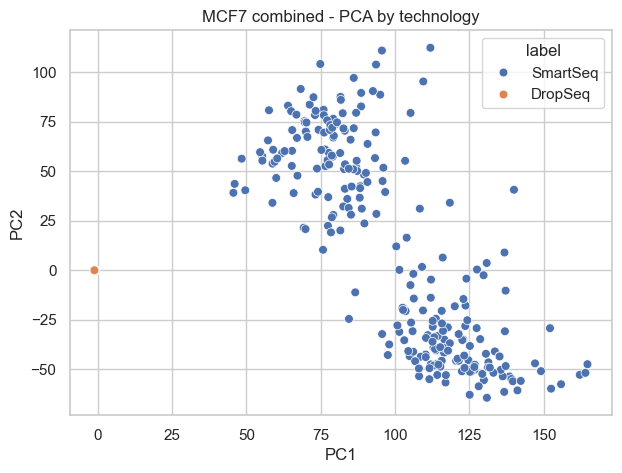

Explained variance ratio: [0.24884558 0.06396284]


In [23]:
pca_plot(
    mcf7_combined,
    labels=mcf7_tech_labels,
    title="MCF7 combined - PCA by technology"
)

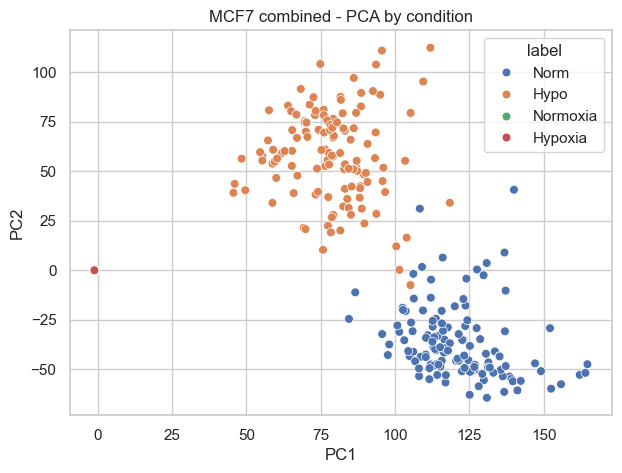

Explained variance ratio: [0.24884558 0.06396284]


In [24]:
pca_plot(
    mcf7_combined,
    labels=mcf7_cond_labels,
    title="MCF7 combined - PCA by condition"
)

In [25]:
# HCC1806 technology comparison
common_genes_hcc = smart_hcc_norm_train.index.intersection(drop_hcc_norm_train.index)

hcc_combined = pd.concat([
    smart_hcc_norm_train.loc[common_genes_hcc],
    drop_hcc_norm_train.loc[common_genes_hcc]
], axis=1)

hcc_tech_labels = pd.Series(
    ["SmartSeq"] * smart_hcc_norm_train.shape[1] + ["DropSeq"] * drop_hcc_norm_train.shape[1],
    index=hcc_combined.columns
)

hcc_cond_labels = pd.concat([smart_hcc_labels, drop_hcc_labels])

print(hcc_combined.shape)

(516, 14864)


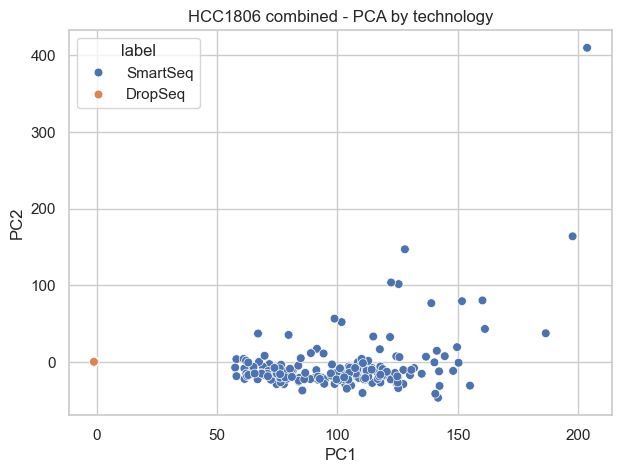

Explained variance ratio: [0.26145437 0.04237131]


In [26]:
pca_plot(
    hcc_combined,
    labels=hcc_tech_labels,
    title="HCC1806 combined - PCA by technology"
)

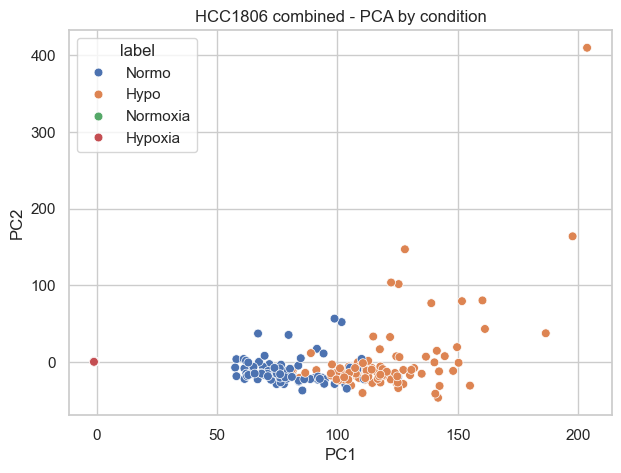

Explained variance ratio: [0.26145437 0.04237131]


In [27]:
pca_plot(
    hcc_combined,
    labels=hcc_cond_labels,
    title="HCC1806 combined - PCA by condition"
)

## 18. Technology comparison interpretation

The combined PCA plots for SmartSeq and DropSeq show a much stronger global structure than the PCA plots within each individual dataset. For MCF7, the first principal component explains about 24.9% of the variance, and for HCC1806 it explains about 26.1%. This is much higher than in the separate PCA analyses, which suggests that sequencing technology introduces a strong source of variation.

This means that when SmartSeq and DropSeq are combined, the platform effect is likely to be one of the main drivers of the separation. In other words, the data structure is influenced not only by biology, such as hypoxia versus normoxia, but also by the sequencing method itself. This is important because it shows that direct comparisons across technologies should be made carefully.

At the same time, condition still matters, but the technology effect seems to be stronger in the combined data. So, these plots suggest that SmartSeq and DropSeq are not perfectly interchangeable, and some of the variation captured by PCA is due to technical differences between the two platforms rather than only biological differences.

## 19. Simple gene-level comparison between conditions

Here I do a very simple comparison:
- average expression in hypoxia
- average expression in normoxia
- difference between them

In [28]:
def simple_condition_comparison(expr, labels):
    labels = labels.loc[expr.columns]
    
    hyp = expr.loc[:, labels.str.contains("Hyp", case=False, na=False)]
    norm = expr.loc[:, labels.str.contains("Norm", case=False, na=False)]
    
    result = pd.DataFrame({
        "mean_hypoxia": hyp.mean(axis=1),
        "mean_normoxia": norm.mean(axis=1)
    })
    
    result["diff"] = result["mean_hypoxia"] - result["mean_normoxia"]
    result["abs_diff"] = result["diff"].abs()
    result = result.sort_values("abs_diff", ascending=False)
    
    return result

In [29]:
mcf7_smart_diff = simple_condition_comparison(smart_mcf7_norm_train, smart_mcf7_labels)
hcc_smart_diff = simple_condition_comparison(smart_hcc_norm_train, smart_hcc_labels)

mcf7_drop_diff = simple_condition_comparison(drop_mcf7_norm_train, drop_mcf7_labels)
hcc_drop_diff = simple_condition_comparison(drop_hcc_norm_train, drop_hcc_labels)

In [30]:
print("Top changing genes in SmartSeq MCF7")
display(mcf7_smart_diff.head(20))

print("Top changing genes in SmartSeq HCC1806")
display(hcc_smart_diff.head(20))

Top changing genes in SmartSeq MCF7


,mean_hypoxia,mean_normoxia,diff,abs_diff
GAPDH,46292.032258,8623.079365,37668.952893,37668.952893
ACTG1,26915.354839,5217.817460,21697.537378,21697.537378
ALDOA,26235.370968,5280.253968,20955.116999,20955.116999
CYP1B1,10696.193548,296.079365,10400.114183,10400.114183
FTH1,10966.370968,3254.865079,7711.505888,7711.505888
PGK1,8696.250000,1379.460317,7316.789683,7316.789683
BEST1,9709.016129,2862.095238,6846.920891,6846.920891
MT-CO1,2497.661290,8972.230159,-6474.568868,6474.568868
GPI,7138.314516,1013.595238,6124.719278,6124.719278
UBC,6946.177419,1625.476190,5320.701229,5320.701229


Top changing genes in SmartSeq HCC1806


,mean_hypoxia,mean_normoxia,diff,abs_diff
LDHA,24055.381443,8955.694118,15099.687326,15099.687326
KRT19,13597.381443,6903.270588,6694.110855,6694.110855
DDIT4,7114.268041,529.011765,6585.256277,6585.256277
ALDOA,10299.670103,4542.941176,5756.728927,5756.728927
FTL,21462.113402,25689.247059,-4227.133657,4227.133657
PGK1,5289.773196,1430.070588,3859.702608,3859.702608
FTH1,13867.432990,11339.929412,2527.503578,2527.503578
ANGPTL4,2261.577320,46.717647,2214.859673,2214.859673
BEST1,12069.711340,9879.823529,2189.887811,2189.887811
HSP90B1,6299.298969,4296.529412,2002.769557,2002.769557


In [31]:
print("Top changing genes in DropSeq MCF7")
display(mcf7_drop_diff.head(20))

print("Top changing genes in DropSeq HCC1806")
display(hcc_drop_diff.head(20))

Top changing genes in DropSeq MCF7


,mean_hypoxia,mean_normoxia,diff,abs_diff
TFF1,3.293241,0.750413,2.542827,2.542827
RPS19,4.048201,1.643684,2.404517,2.404517
MALAT1,2.367672,4.524518,-2.156846,2.156846
RPL13,2.500617,0.931523,1.569094,1.569094
RPL35,2.322385,0.936088,1.386297,1.386297
RPS14,2.147069,0.781897,1.365172,1.365172
MT-RNR2,0.097523,1.379142,-1.281619,1.281619
RPL12,1.685798,0.631090,1.054707,1.054707
TMSB10,1.238426,0.196773,1.041653,1.041653
RPLP1,1.800022,0.820622,0.979401,0.979401


Top changing genes in DropSeq HCC1806


,mean_hypoxia,mean_normoxia,diff,abs_diff
BCYRN1,0.660411,1.619402,-0.958990,0.958990
HSP90AA1,1.185976,2.102888,-0.916912,0.916912
HSP90AB1,1.104956,1.866159,-0.761204,0.761204
MALAT1,1.640634,2.297423,-0.656790,0.656790
AKR1C2,0.350489,1.005015,-0.654526,0.654526
H4C3,3.118890,3.745980,-0.627090,0.627090
NCL,0.806270,1.426941,-0.620671,0.620671
HSPD1,0.559838,1.162545,-0.602707,0.602707
RPL41,1.464547,0.864603,0.599943,0.599943
ENO1,1.724239,1.197130,0.527109,0.527109


## 20. Do the same top genes appear in different datasets?

Here I check whether some of the strongest genes appear again across technologies or cell lines.

That is useful because repeated genes may reflect a more stable biological signal.

In [32]:
top20_mcf7_smart = set(mcf7_smart_diff.head(20).index)
top20_mcf7_drop = set(mcf7_drop_diff.head(20).index)

top20_hcc_smart = set(hcc_smart_diff.head(20).index)
top20_hcc_drop = set(hcc_drop_diff.head(20).index)

print("Overlap MCF7 SmartSeq vs DropSeq:", top20_mcf7_smart.intersection(top20_mcf7_drop))
print("Overlap HCC1806 SmartSeq vs DropSeq:", top20_hcc_smart.intersection(top20_hcc_drop))

Overlap MCF7 SmartSeq vs DropSeq: set()
Overlap HCC1806 SmartSeq vs DropSeq: {'LDHA', 'IGFBP3', 'TMSB10'}


## 21. Train a simple classifier

The instructions mention that normalized data can be used for classifiers.

In [33]:
def prepare_xy(expr, labels):
    X = expr.T.copy()  # samples x genes
    y = labels.loc[X.index].copy()
    
    # make labels simple: Hypoxia = 1, Normoxia = 0
    y = y.astype(str)
    y_bin = y.str.contains("Hyp", case=False, na=False).astype(int)
    
    return X, y_bin

In [34]:
def evaluate_logistic_regression(expr, labels, dataset_name):
    X, y = prepare_xy(expr, labels)
    
    model = LogisticRegression(max_iter=3000)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    
    print(f"{dataset_name}")
    print("CV accuracies:", scores)
    print("Mean CV accuracy:", scores.mean())
    print("-" * 50)
    
    return scores.mean()

In [35]:
results = {}

results["SmartSeq MCF7"] = evaluate_logistic_regression(
    smart_mcf7_norm_train, smart_mcf7_labels, "SmartSeq MCF7"
)

results["SmartSeq HCC1806"] = evaluate_logistic_regression(
    smart_hcc_norm_train, smart_hcc_labels, "SmartSeq HCC1806"
)

results["DropSeq MCF7"] = evaluate_logistic_regression(
    drop_mcf7_norm_train, drop_mcf7_labels, "DropSeq MCF7"
)

results["DropSeq HCC1806"] = evaluate_logistic_regression(
    drop_hcc_norm_train, drop_hcc_labels, "DropSeq HCC1806"
)

SmartSeq MCF7
CV accuracies: [1. 1. 1. 1. 1.]
Mean CV accuracy: 1.0
--------------------------------------------------
SmartSeq HCC1806
CV accuracies: [1.         0.94594595 1.         0.94444444 0.94444444]
Mean CV accuracy: 0.9669669669669669
--------------------------------------------------
DropSeq MCF7
CV accuracies: [0.97480351 0.97872832 0.97780347 0.97849711 0.97942197]
Mean CV accuracy: 0.9778508761380976
--------------------------------------------------
DropSeq HCC1806
CV accuracies: [0.94620361 0.94552264 0.95027248 0.95401907 0.95504087]
Mean CV accuracy: 0.9502117352689865
--------------------------------------------------


In [36]:
pd.DataFrame({
    "dataset": list(results.keys()),
    "mean_cv_accuracy": list(results.values())
}).sort_values("mean_cv_accuracy", ascending=False)

,dataset,mean_cv_accuracy
0,SmartSeq MCF7,1.000000
2,DropSeq MCF7,0.977851
1,SmartSeq HCC1806,0.966967
3,DropSeq HCC1806,0.950212


## 22. Random Forest

I also try a random forest just to compare.

In [37]:
def evaluate_random_forest(expr, labels, dataset_name):
    X, y = prepare_xy(expr, labels)
    
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    
    print(f"{dataset_name}")
    print("CV accuracies:", scores)
    print("Mean CV accuracy:", scores.mean())
    print("-" * 50)
    
    return scores.mean()

In [38]:
rf_results = {}

rf_results["SmartSeq MCF7"] = evaluate_random_forest(
    smart_mcf7_norm_train, smart_mcf7_labels, "SmartSeq MCF7"
)

rf_results["SmartSeq HCC1806"] = evaluate_random_forest(
    smart_hcc_norm_train, smart_hcc_labels, "SmartSeq HCC1806"
)

rf_results["DropSeq MCF7"] = evaluate_random_forest(
    drop_mcf7_norm_train, drop_mcf7_labels, "DropSeq MCF7"
)

rf_results["DropSeq HCC1806"] = evaluate_random_forest(
    drop_hcc_norm_train, drop_hcc_labels, "DropSeq HCC1806"
)

SmartSeq MCF7
CV accuracies: [1.   1.   1.   0.98 1.  ]
Mean CV accuracy: 0.9960000000000001
--------------------------------------------------
SmartSeq HCC1806
CV accuracies: [1.         0.97297297 1.         1.         0.97222222]
Mean CV accuracy: 0.989039039039039
--------------------------------------------------
DropSeq MCF7
CV accuracies: [0.96740638 0.96578035 0.96439306 0.96462428 0.96901734]
Mean CV accuracy: 0.9662442817858947
--------------------------------------------------
DropSeq HCC1806
CV accuracies: [0.93326524 0.9339462  0.9349455  0.93392371 0.9373297 ]
Mean CV accuracy: 0.9346820700653783
--------------------------------------------------


In [39]:
model_compare = pd.DataFrame({
    "dataset": list(results.keys()),
    "logistic_regression_accuracy": list(results.values()),
    "random_forest_accuracy": [rf_results[k] for k in results.keys()]
})

model_compare

,dataset,logistic_regression_accuracy,random_forest_accuracy
0,SmartSeq MCF7,1.000000,0.996000
1,SmartSeq HCC1806,0.966967,0.989039
2,DropSeq MCF7,0.977851,0.966244
3,DropSeq HCC1806,0.950212,0.934682


## 23. Final discussion

- In this notebook, I looked at gene expression data from 2 cell lines, MCF7 and HCC1806, and from 2 sequencing technologies, SmartSeq and DropSeq.

- The raw SmartSeq data already showed some clear problems, like lots of zero values, big differences between cells, and a lot of variation in total counts and detected genes.

- This is important because it shows why preprocessing is needed before doing more serious analysis. If I used only the raw data, a lot of the patterns could be harder to interpret.

- After filtering, the data became less sparse and easier to work with. The zero fraction dropped in both cell lines, which suggests that filtering removed some of the low-information genes and noise.

- The PCA plots showed that the overall structure is not equally strong in every dataset. SmartSeq had a clearer structure in the first two principal components, while DropSeq looked more spread out.

- This probably means that the signal is easier to see in SmartSeq in low dimensions, while in DropSeq the variation may be more complex and spread across more components.

- When I combined SmartSeq and DropSeq for the same cell line, the PCA separation became much stronger. This suggests that the sequencing technology itself has a big effect on the data.

- So, not all differences in the plots come from biology. Some of them are likely caused by the platform, which means I should be careful when comparing SmartSeq and DropSeq directly.

- The simple gene comparison showed that some genes change a lot between hypoxia and normoxia, but the overlap between technologies was not very large.

- For MCF7, there was no overlap in the top 20 genes between SmartSeq and DropSeq. For HCC1806, there were a few genes in common, like LDHA, TMSB10, and IGFBP3.

- This could mean that some hypoxia-related genes are more stable in HCC1806, or just that MCF7 is more affected by differences between technologies.

- The classification results were still very strong, which means the normalized data clearly contains useful information about the condition.

- Logistic regression performed very well in all datasets, and random forest also gave high accuracy, especially in the SmartSeq datasets.

- Overall, the notebook suggests that both biology and technology matter. The condition signal is definitely there, but the platform also changes the structure of the data quite a lot.

- So the main conclusion is that the normalized datasets are good for exploration and classification, but cross-technology comparisons should be interpreted carefully because some of the separation may come from technical differences and not only from biology.

## UMAP visualization

UMAP is a non-linear dimensionality reduction method.

Compared to PCA:
- PCA captures linear structure
- UMAP can capture more complex patterns

It often shows clearer clusters in biological data.

In [40]:
import umap

def umap_plot(expr, labels=None, title="UMAP plot"):
    X = expr.T.copy()  # samples x genes
    
    # scale data
    X_scaled = StandardScaler().fit_transform(X)
    
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )
    
    embedding = reducer.fit_transform(X_scaled)
    
    plot_df = pd.DataFrame({
        "UMAP1": embedding[:, 0],
        "UMAP2": embedding[:, 1]
    }, index=X.index)
    
    plt.figure(figsize=(7, 5))
    
    if labels is None:
        plt.scatter(plot_df["UMAP1"], plot_df["UMAP2"], s=25)
    else:
        plot_df["label"] = labels.loc[plot_df.index].values
        sns.scatterplot(data=plot_df, x="UMAP1", y="UMAP2", hue="label", s=40)
    
    plt.title(title)
    plt.show()

c:\Users\hugoo\miniconda3\envs\ai-lab-report\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


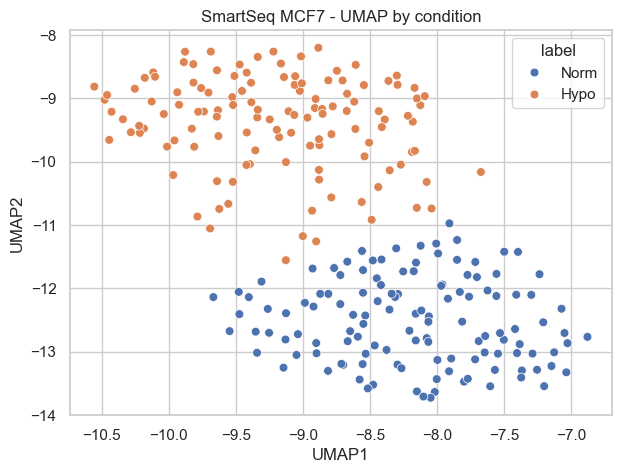

c:\Users\hugoo\miniconda3\envs\ai-lab-report\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


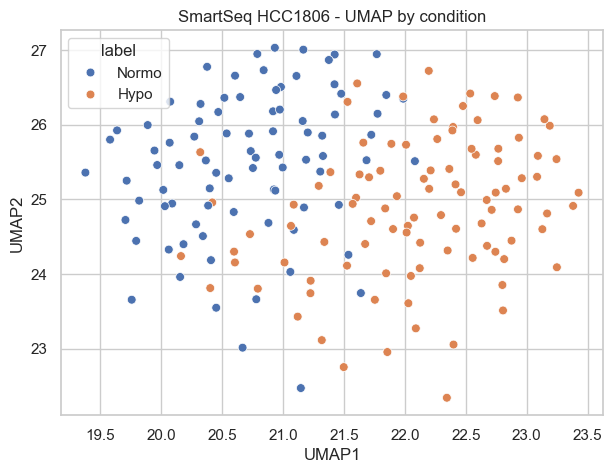

c:\Users\hugoo\miniconda3\envs\ai-lab-report\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


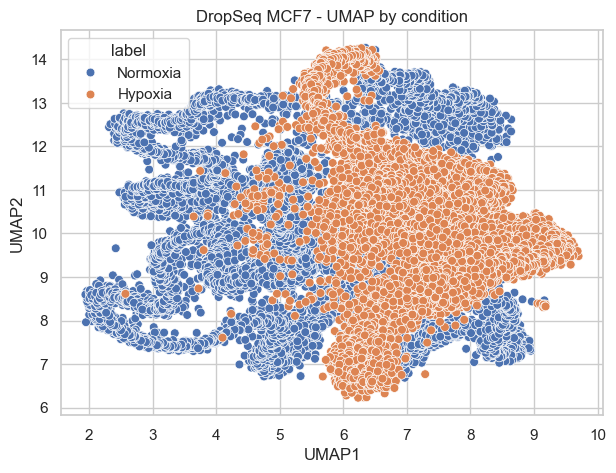

c:\Users\hugoo\miniconda3\envs\ai-lab-report\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


MemoryError: Allocation failed (probably too large).

In [41]:
# UMAP for every normalized training dataset.
normalized_training_datasets = {
    "SmartSeq MCF7": (smart_mcf7_norm_train, smart_mcf7_labels),
    "SmartSeq HCC1806": (smart_hcc_norm_train, smart_hcc_labels),
    "DropSeq MCF7": (drop_mcf7_norm_train, drop_mcf7_labels),
    "DropSeq HCC1806": (drop_hcc_norm_train, drop_hcc_labels),
}

for dataset_name, (expr, labels) in normalized_training_datasets.items():
    umap_plot(
        expr,
        labels=labels,
        title=f"{dataset_name} - UMAP by condition"
    )


## t-SNE visualization

t-SNE focuses on local structure:
- it tries to keep similar samples close
- it often creates clear clusters

However:
- it can distort global distances
- results can change depending on parameters

In [ ]:
from sklearn.manifold import TSNE

def tsne_plot(expr, labels=None, title="t-SNE plot"):
    X = expr.T.copy()
    X_scaled = StandardScaler().fit_transform(X)
    # Use a safe perplexity for smaller datasets.
    safe_perplexity = min(30, max(5, (X.shape[0] - 1) // 3))
    
    tsne = TSNE(
        n_components=2,
        perplexity=safe_perplexity,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    
    embedding = tsne.fit_transform(X_scaled)
    
    plot_df = pd.DataFrame({
        "TSNE1": embedding[:, 0],
        "TSNE2": embedding[:, 1]
    }, index=X.index)
    
    plt.figure(figsize=(7, 5))
    if labels is None:
        plt.scatter(plot_df["TSNE1"], plot_df["TSNE2"], s=25)
    else:
        plot_df["label"] = labels.loc[plot_df.index].values
        sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="label", s=40)
    
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [ ]:
# t-SNE for every normalized training dataset.
for dataset_name, (expr, labels) in normalized_training_datasets.items():
    tsne_plot(
        expr,
        labels=labels,
        title=f"{dataset_name} - t-SNE by condition"
    )


## K-Means clustering

Here I try unsupervised clustering.

This means:
- the model does not use labels
- it tries to find structure on its own

Then I compare clusters with real conditions.

In [ ]:
def kmeans_clustering(expr, labels, k=2):
    X = expr.T.copy()
    X_scaled = StandardScaler().fit_transform(X)
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    
    result = pd.DataFrame({
        "cluster": clusters,
        "true_label": labels.loc[X.index].values
    })
    
    print(pd.crosstab(result["cluster"], result["true_label"]))
    
    return result

In [ ]:
# K-means clustering for every normalized training dataset.
for dataset_name, (expr, labels) in normalized_training_datasets.items():
    print("\n" + "=" * 80)
    print(dataset_name)
    kmeans_clustering(expr, labels)


## Feature importance

Here I check which genes are most important for prediction.

This helps connect machine learning results back to biology.

In [ ]:
from xgboost import XGBClassifier

In [ ]:
def feature_importance_xgb(expr, labels, dataset_name="Dataset", top_n=20):
    X, y = prepare_xy(expr, labels)
    
    model = XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric="logloss"
    )
    model.fit(X, y)
    
    importance = pd.Series(model.feature_importances_, index=X.columns)
    top = importance.sort_values(ascending=False).head(top_n)
    
    plt.figure(figsize=(8, 5))
    top[::-1].plot(kind="barh")
    plt.title(f"{dataset_name}: top {top_n} important genes from XGBoost")
    plt.xlabel("XGBoost feature importance")
    plt.tight_layout()
    plt.show()
    
    return top


In [ ]:
# XGBoost feature-importance plot for every normalized training dataset.
xgb_top_genes = {}
for dataset_name, (expr, labels) in normalized_training_datasets.items():
    xgb_top_genes[dataset_name] = feature_importance_xgb(expr, labels, dataset_name=dataset_name, top_n=20)
    display(pd.DataFrame({"gene": xgb_top_genes[dataset_name].index, "importance": xgb_top_genes[dataset_name].values}).head(20))


## UMAP colored by technology and condition

Here I combine SmartSeq and DropSeq for the same cell line, then color each point using both:
- the sequencing technology
- the biological condition

This helps show whether the structure is mainly driven by technology, condition, or both.

In [ ]:
import umap

def combined_umap_technology_condition(smart_expr, smart_labels, drop_expr, drop_labels, cell_line_name):
    common_genes = smart_expr.index.intersection(drop_expr.index)

    combined = pd.concat([
        smart_expr.loc[common_genes],
        drop_expr.loc[common_genes]
    ], axis=1)

    technology = pd.Series(
        ["SmartSeq"] * smart_expr.shape[1] + ["DropSeq"] * drop_expr.shape[1],
        index=combined.columns,
        name="Technology"
    )

    condition = pd.concat([smart_labels, drop_labels])
    condition = condition.loc[combined.columns]

    combined_label = technology + " | " + condition.astype(str)

    X = combined.T.copy()
    X_scaled = StandardScaler().fit_transform(X)

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )

    embedding = reducer.fit_transform(X_scaled)

    plot_df = pd.DataFrame({
        "UMAP1": embedding[:, 0],
        "UMAP2": embedding[:, 1],
        "Technology": technology.values,
        "Condition": condition.values,
        "Technology + Condition": combined_label.values
    }, index=combined.columns)

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=plot_df,
        x="UMAP1",
        y="UMAP2",
        hue="Technology + Condition",
        s=45
    )
    plt.title(f"{cell_line_name} - UMAP colored by technology and condition")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()

    return plot_df

c:\Users\hugoo\miniconda3\envs\ai-lab-report\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


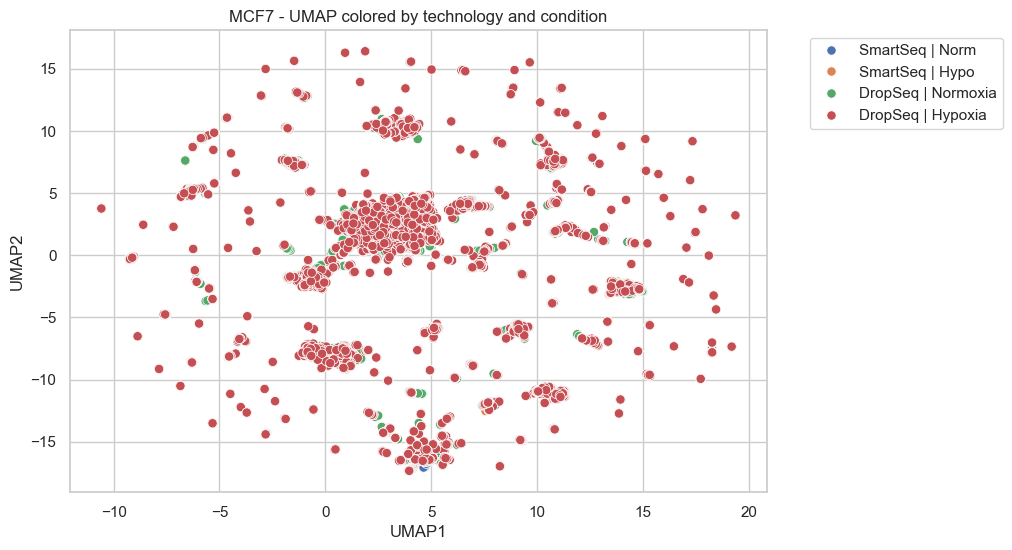

In [ ]:
mcf7_umap_tech_condition = combined_umap_technology_condition(
    smart_mcf7_norm_train,
    smart_mcf7_labels,
    drop_mcf7_norm_train,
    drop_mcf7_labels,
    "MCF7"
)

c:\Users\hugoo\miniconda3\envs\ai-lab-report\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


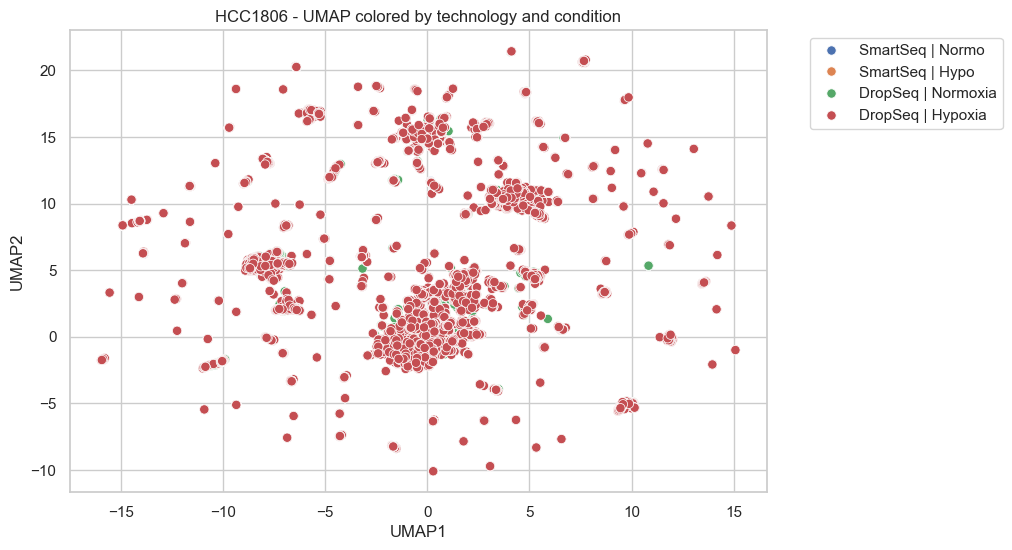

In [ ]:
hcc_umap_tech_condition = combined_umap_technology_condition(
    smart_hcc_norm_train,
    smart_hcc_labels,
    drop_hcc_norm_train,
    drop_hcc_labels,
    "HCC1806"
)

# Professor Extension: biological interpretation, hypoxia signatures, and cross-cell-line validation

This section addresses the optional extensions suggested by the professor. The aim is not only to show that hypoxia can be predicted, but also to ask whether the models recover biologically meaningful hypoxia biology.

The attached `DataInterpretation_resources.pdf` recommends interpreting predictive genes using pathway/signature analysis. It distinguishes ORA, which tests whether a selected list of important genes is enriched in known gene sets, from GSEA, which uses a full ranked gene list. It also highlights hypoxia resources such as MSigDB Hallmark Hypoxia, Buffa, Winter/Ragnum hypoxia metagenes, and direct HIF target genes.

The analyses below add:

1. model-based feature importance for MCF7 and HCC1806;
2. overlap with hypoxia/HIF target genes from the provided interpretation document;
3. ORA-style enrichment using a hypergeometric test;
4. comparison of important genes across cell lines;
5. cross-cell-line generalization experiments;
6. a combined model trained across both cell lines.


In [ ]:

# =============================
# Professor Extension Utilities
# =============================
from pathlib import Path
import re
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

try:
    from scipy.stats import hypergeom
except Exception:
    hypergeom = None

# Keep the exact same path setup as the original notebook.
# BASE, SMART and DROP are defined in the setup cell above.
OUTPUT = BASE.parent / "ai_lab_outputs"
OUTPUT.mkdir(exist_ok=True)

DATASETS = {
    "MCF7": SMART / "MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt",
    "HCC1806": SMART / "HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt",
}

def load_expression_matrix(path):
    """Load expression data with genes as rows and cells/samples as columns."""
    df = pd.read_csv(path, sep=r"\s+", engine="python", index_col=0)
    df.index = df.index.astype(str).str.replace('"', '', regex=False)
    df.columns = df.columns.astype(str).str.replace('"', '', regex=False)
    # Drop accidental numeric/header rows if present
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(how="all")
    return df

def labels_from_columns(cols):
    labels = []
    for c in cols:
        low = c.lower()
        if "hypo" in low or "hypoxia" in low:
            labels.append(1)
        elif "norm" in low or "normoxia" in low:
            labels.append(0)
        else:
            labels.append(np.nan)
    return np.array(labels, dtype=float)

def prepare_xy(expr):
    y = labels_from_columns(expr.columns)
    keep = ~np.isnan(y)
    X = expr.loc[:, keep].T.copy()
    y = y[keep].astype(int)
    # Remove constant genes for cleaner models
    X = X.loc[:, X.var(axis=0) > 0]
    return X, y

loaded = {}
for name, path in DATASETS.items():
    expr = load_expression_matrix(path)
    X, y = prepare_xy(expr)
    loaded[name] = {"expr": expr, "X": X, "y": y}
    print(f"{name}: expression={expr.shape}, ML matrix={X.shape}, hypoxia={int(y.sum())}, normoxia={int((1-y).sum())}")


MCF7: expression=(3000, 250), ML matrix=(250, 3000), hypoxia=124, normoxia=126
HCC1806: expression=(3000, 182), ML matrix=(182, 3000), hypoxia=97, normoxia=85


In [ ]:

# =======================================================
# Hypoxia / HIF gene sets from DataInterpretation_resources
# =======================================================
# These sets are built from the professor's PDF:
# - direct HIF target genes and biological categories named in section 3.2
# - resources/signatures mentioned in sections 3.3-3.7
# For a final publication-grade analysis, replace/extend these with full MSigDB .gmt files.

GENE_SETS = {
    "PDF_HIF_GLYCOLYSIS": {
        "SLC2A1", "SLC2A3", "HK1", "HK2", "PFKL", "ALDOA", "PGAM1", "ENO1", "LDHA", "PDK1", "PFKFB3"
    },
    "PDF_HIF_ANGIOGENESIS": {"VEGFA", "VEGFC", "ANGPT2", "FLT1", "NRP1"},
    "PDF_HIF_PH_REGULATION": {"CA9", "CA12", "SLC9A1"},
    "PDF_HIF_SURVIVAL_APOPTOSIS": {"BNIP3", "BNIP3L", "BCL2L1"},
    "PDF_HIF_ERYTHROPOIESIS": {"EPO", "TFRC"},
    "PDF_HIF_ECM_INVASION": {"LOX", "MMP2", "CXCR4"},
    "PDF_HIF_CELL_CYCLE": {"CDKN1A", "CCND1"},
}
GENE_SETS["PDF_DIRECT_HIF_TARGETS_COMBINED"] = set().union(*GENE_SETS.values())

# A compact literature-style hypoxia marker set useful for overlap checks. The professor's PDF points to
# Hallmark, Buffa, Winter, Ragnum and GO:0001666; many of these require MSigDB download/login. This local
# marker set keeps the notebook fully runnable offline while still testing the expected biology.
GENE_SETS["LOCAL_COMPACT_HYPOXIA_SIGNATURE"] = {
    "DDIT4", "NDRG1", "BNIP3", "BNIP3L", "CA9", "CA12", "VEGFA", "ADM", "ANGPTL4", "EGLN1", "EGLN3",
    "ENO1", "LDHA", "PDK1", "PFKFB3", "HK2", "SLC2A1", "SLC2A3", "PGK1", "ALDOA", "P4HA1", "P4HA2",
    "LOX", "MMP2", "CXCR4", "TFRC", "BHLHE40", "KDM3A", "ANKRD37", "PLOD2", "SERPINE1", "ERO1A"
}
GENE_SETS["PDF_ALL_HYPOXIA_RELATED"] = GENE_SETS["PDF_DIRECT_HIF_TARGETS_COMBINED"] | GENE_SETS["LOCAL_COMPACT_HYPOXIA_SIGNATURE"]

print("Gene sets available:")
for k, v in GENE_SETS.items():
    print(f"{k}: {len(v)} genes")


Gene sets available:
PDF_HIF_GLYCOLYSIS: 11 genes
PDF_HIF_ANGIOGENESIS: 5 genes
PDF_HIF_PH_REGULATION: 3 genes
PDF_HIF_SURVIVAL_APOPTOSIS: 3 genes
PDF_HIF_ERYTHROPOIESIS: 2 genes
PDF_HIF_ECM_INVASION: 3 genes
PDF_HIF_CELL_CYCLE: 2 genes
PDF_DIRECT_HIF_TARGETS_COMBINED: 29 genes
LOCAL_COMPACT_HYPOXIA_SIGNATURE: 32 genes
PDF_ALL_HYPOXIA_RELATED: 44 genes


In [ ]:

# ================================================
# Train models and extract predictive gene rankings
# ================================================

def safe_auc(y_true, proba):
    try:
        return roc_auc_score(y_true, proba)
    except Exception:
        return np.nan

MODELS = {
    "RandomForest": RandomForestClassifier(n_estimators=120, random_state=42, class_weight="balanced", n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=120, random_state=42, class_weight="balanced", n_jobs=-1),
    "Logistic_L1": make_pipeline(
        StandardScaler(with_mean=True),
        LogisticRegression(penalty="l1", solver="liblinear", C=0.5, class_weight="balanced", max_iter=5000, random_state=42)
    ),
}

def fit_and_rank(X, y, model_name="RandomForest"):
    model = MODELS[model_name]
    model.fit(X, y)
    if model_name == "Logistic_L1":
        clf = model.named_steps["logisticregression"]
        importance = np.abs(clf.coef_[0])
    else:
        importance = getattr(model, "feature_importances_", np.zeros(X.shape[1]))
    ranks = pd.DataFrame({"gene": X.columns, "importance": importance}).sort_values("importance", ascending=False)
    ranks["rank"] = np.arange(1, len(ranks) + 1)
    return model, ranks

rankings = {}
model_metrics = []
for cell_line, obj in loaded.items():
    X, y = obj["X"], obj["y"]
    rankings[cell_line] = {}
    for model_name in MODELS:
        # small holdout evaluation for report table
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
        model, ranks = fit_and_rank(Xtr, ytr, model_name)
        preds = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else preds
        model_metrics.append({
            "cell_line": cell_line,
            "model": model_name,
            "accuracy": accuracy_score(yte, preds),
            "f1": f1_score(yte, preds),
            "roc_auc": safe_auc(yte, proba),
            "n_train": len(ytr),
            "n_test": len(yte),
        })
        # refit on all samples for final feature ranking
        full_model, full_ranks = fit_and_rank(X, y, model_name)
        rankings[cell_line][model_name] = full_ranks
        full_ranks.to_csv(OUTPUT / f"{cell_line}_{model_name}_gene_importance.csv", index=False)

metrics_df = pd.DataFrame(model_metrics).sort_values(["cell_line", "model"])
display(metrics_df)
metrics_df.to_csv(OUTPUT / "supervised_model_metrics.csv", index=False)


,cell_line,model,accuracy,f1,roc_auc,n_train,n_test
4,HCC1806,ExtraTrees,1.000000,1.000000,1.0,136,46
5,HCC1806,Logistic_L1,0.978261,0.979592,1.0,136,46
3,HCC1806,RandomForest,1.000000,1.000000,1.0,136,46
1,MCF7,ExtraTrees,1.000000,1.000000,1.0,187,63
2,MCF7,Logistic_L1,1.000000,1.000000,1.0,187,63
0,MCF7,RandomForest,1.000000,1.000000,1.0,187,63


In [ ]:

# ====================================================
# Compare important genes with hypoxia/HIF gene sets
# ====================================================

def annotate_with_gene_sets(ranks, gene_sets=GENE_SETS):
    out = ranks.copy()
    gene_upper = out["gene"].str.upper()
    for name, genes in gene_sets.items():
        genes_upper = {g.upper() for g in genes}
        out[name] = gene_upper.isin(genes_upper)
    out["n_hypoxia_sets_hit"] = out[[c for c in out.columns if c.startswith("PDF_") or c.startswith("LOCAL_")]].sum(axis=1)
    return out

annotated_rankings = {}
summary_rows = []
for cell_line in rankings:
    annotated_rankings[cell_line] = {}
    for model_name, ranks in rankings[cell_line].items():
        ann = annotate_with_gene_sets(ranks)
        annotated_rankings[cell_line][model_name] = ann
        ann.to_csv(OUTPUT / f"{cell_line}_{model_name}_gene_importance_annotated.csv", index=False)
        for top_n in [25, 50, 100, 200]:
            top = ann.head(top_n)
            summary_rows.append({
                "cell_line": cell_line,
                "model": model_name,
                "top_n": top_n,
                "hypoxia_related_hits": int(top["PDF_ALL_HYPOXIA_RELATED"].sum()),
                "direct_HIF_target_hits": int(top["PDF_DIRECT_HIF_TARGETS_COMBINED"].sum()),
                "compact_signature_hits": int(top["LOCAL_COMPACT_HYPOXIA_SIGNATURE"].sum()),
                "example_hypoxia_genes": ", ".join(top.loc[top["PDF_ALL_HYPOXIA_RELATED"], "gene"].head(12).tolist())
            })

hypoxia_overlap_summary = pd.DataFrame(summary_rows)
display(hypoxia_overlap_summary)
hypoxia_overlap_summary.to_csv(OUTPUT / "hypoxia_signature_overlap_summary.csv", index=False)

# Show top biologically interpretable genes from the best default model
for cell_line in annotated_rankings:
    print("\n", cell_line, "RandomForest top genes that overlap the hypoxia/HIF sets")
    display(annotated_rankings[cell_line]["RandomForest"].query("PDF_ALL_HYPOXIA_RELATED").head(20))


,cell_line,model,top_n,hypoxia_related_hits,direct_HIF_target_hits,compact_signature_hits,example_hypoxia_genes
0,MCF7,RandomForest,25,6,3,6,"BNIP3, ALDOA, P4HA1, ERO1A, HK2, DDIT4"
1,MCF7,RandomForest,50,10,5,10,"BNIP3, ALDOA, P4HA1, ERO1A, HK2, DDIT4, LDHA, ..."
2,MCF7,RandomForest,100,13,7,13,"BNIP3, ALDOA, P4HA1, ERO1A, HK2, DDIT4, LDHA, ..."
3,MCF7,RandomForest,200,20,11,19,"BNIP3, ALDOA, P4HA1, ERO1A, HK2, DDIT4, LDHA, ..."
4,MCF7,ExtraTrees,25,2,1,2,"BNIP3, NDRG1"
5,MCF7,ExtraTrees,50,6,3,6,"BNIP3, NDRG1, P4HA1, PDK1, PGK1, BNIP3L"
6,MCF7,ExtraTrees,100,10,5,10,"BNIP3, NDRG1, P4HA1, PDK1, PGK1, BNIP3L, DDIT4..."
7,MCF7,ExtraTrees,200,14,8,14,"BNIP3, NDRG1, P4HA1, PDK1, PGK1, BNIP3L, DDIT4..."
8,MCF7,Logistic_L1,25,2,0,2,"PGK1, NDRG1"
9,MCF7,Logistic_L1,50,4,2,4,"PGK1, NDRG1, PDK1, LDHA"



 MCF7 RandomForest top genes that overlap the hypoxia/HIF sets


,gene,importance,rank,PDF_HIF_GLYCOLYSIS,PDF_HIF_ANGIOGENESIS,PDF_HIF_PH_REGULATION,PDF_HIF_SURVIVAL_APOPTOSIS,PDF_HIF_ERYTHROPOIESIS,PDF_HIF_ECM_INVASION,PDF_HIF_CELL_CYCLE,PDF_DIRECT_HIF_TARGETS_COMBINED,LOCAL_COMPACT_HYPOXIA_SIGNATURE,PDF_ALL_HYPOXIA_RELATED,n_hypoxia_sets_hit
22,BNIP3,0.037385,1,False,False,False,True,False,False,False,True,True,True,4
2591,ALDOA,0.025269,6,True,False,False,False,False,False,False,True,True,True,4
450,P4HA1,0.021383,7,False,False,False,False,False,False,False,False,True,True,2
298,ERO1A,0.016323,13,False,False,False,False,False,False,False,False,True,True,2
6,HK2,0.014465,16,True,False,False,False,False,False,False,True,True,True,4
4,DDIT4,0.012859,22,False,False,False,False,False,False,False,False,True,True,2
228,LDHA,0.008589,36,True,False,False,False,False,False,False,True,True,True,4
3,NDRG1,0.008460,37,False,False,False,False,False,False,False,False,True,True,2
224,PGK1,0.007828,40,False,False,False,False,False,False,False,False,True,True,2
595,PDK1,0.007439,46,True,False,False,False,False,False,False,True,True,True,4



 HCC1806 RandomForest top genes that overlap the hypoxia/HIF sets


,gene,importance,rank,PDF_HIF_GLYCOLYSIS,PDF_HIF_ANGIOGENESIS,PDF_HIF_PH_REGULATION,PDF_HIF_SURVIVAL_APOPTOSIS,PDF_HIF_ERYTHROPOIESIS,PDF_HIF_ECM_INVASION,PDF_HIF_CELL_CYCLE,PDF_DIRECT_HIF_TARGETS_COMBINED,LOCAL_COMPACT_HYPOXIA_SIGNATURE,PDF_ALL_HYPOXIA_RELATED,n_hypoxia_sets_hit
8,NDRG1,0.035594,1,False,False,False,False,False,False,False,False,True,True,2
0,DDIT4,0.031216,3,False,False,False,False,False,False,False,False,True,True,2
2470,EGLN1,0.028394,4,False,False,False,False,False,False,False,False,True,True,2
1,ANGPTL4,0.026946,5,False,False,False,False,False,False,False,False,True,True,2
2304,BNIP3L,0.026800,6,False,False,False,True,False,False,False,True,True,True,4
22,CA9,0.022904,8,False,False,True,False,False,False,False,True,True,True,4
1141,P4HA1,0.020307,9,False,False,False,False,False,False,False,False,True,True,2
299,PFKFB3,0.020278,10,True,False,False,False,False,False,False,True,True,True,4
62,BNIP3,0.018560,11,False,False,False,True,False,False,False,True,True,True,4
101,SLC2A1,0.018199,13,True,False,False,False,False,False,False,True,True,True,4


,cell_line,model,gene_set,overlap,selected_n,set_size_in_background,background_n,p_value,overlap_genes,FDR_BH
40,HCC1806,ExtraTrees,PDF_ALL_HYPOXIA_RELATED,23,100,32,3000,1.662318e-28,"ADM, ALDOA, ANGPTL4, BHLHE40, BNIP3, BNIP3L, C...",1.662318e-27
41,HCC1806,ExtraTrees,LOCAL_COMPACT_HYPOXIA_SIGNATURE,21,100,28,3000,1.058394e-26,"ADM, ALDOA, ANGPTL4, BHLHE40, BNIP3, BNIP3L, C...",5.291969e-26
42,HCC1806,ExtraTrees,PDF_DIRECT_HIF_TARGETS_COMBINED,10,100,18,3000,3.784542e-11,"ALDOA, BNIP3, BNIP3L, CA9, CDKN1A, HK2, LDHA, ...",1.261514e-10
43,HCC1806,ExtraTrees,PDF_HIF_GLYCOLYSIS,6,100,8,3000,3.137182e-08,"ALDOA, HK2, LDHA, PFKFB3, PFKL, SLC2A1",7.842955e-08
44,HCC1806,ExtraTrees,PDF_HIF_SURVIVAL_APOPTOSIS,2,100,2,3000,1.100367e-03,"BNIP3, BNIP3L",2.200734e-03
45,HCC1806,ExtraTrees,PDF_HIF_CELL_CYCLE,1,100,1,3000,3.333333e-02,CDKN1A,5.555556e-02
46,HCC1806,ExtraTrees,PDF_HIF_PH_REGULATION,1,100,2,3000,6.556630e-02,CA9,9.366614e-02
47,HCC1806,ExtraTrees,PDF_HIF_ANGIOGENESIS,0,100,2,3000,1.000000e+00,,1.000000e+00
48,HCC1806,ExtraTrees,PDF_HIF_ERYTHROPOIESIS,0,100,1,3000,1.000000e+00,,1.000000e+00
49,HCC1806,ExtraTrees,PDF_HIF_ECM_INVASION,0,100,2,3000,1.000000e+00,,1.000000e+00


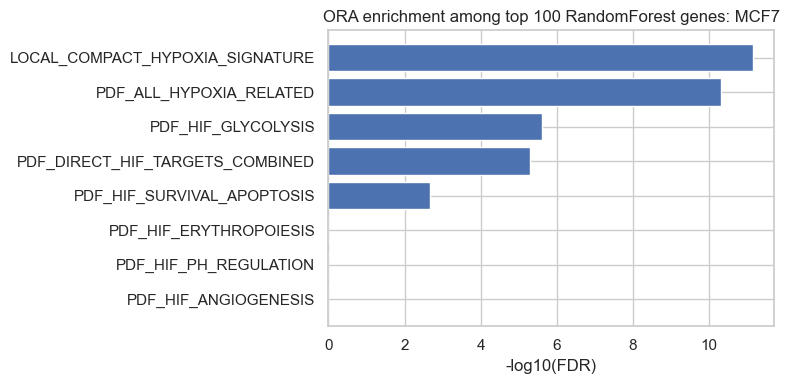

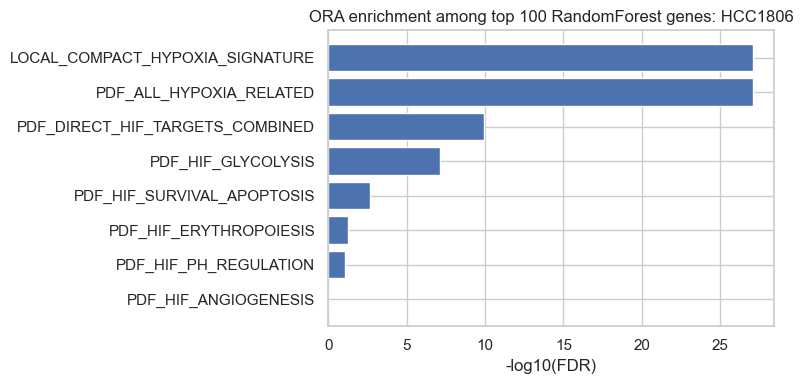

In [ ]:

# ==========================================
# ORA enrichment using hypergeometric testing
# ==========================================

def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.minimum(q, 1.0)
    return out

def ora_enrichment(selected_genes, background_genes, gene_sets=GENE_SETS):
    selected = {g.upper() for g in selected_genes}
    background = {g.upper() for g in background_genes}
    selected = selected & background
    M = len(background)
    n = len(selected)
    rows = []
    for set_name, genes in gene_sets.items():
        gs = {g.upper() for g in genes} & background
        K = len(gs)
        x = len(selected & gs)
        if M == 0 or n == 0 or K == 0:
            p = 1.0
        elif hypergeom is not None:
            p = hypergeom.sf(x - 1, M, K, n)
        else:
            # fallback: simple Fisher-like tail using combinations
            from math import comb
            denom = comb(M, n)
            p = sum(comb(K, i) * comb(M-K, n-i) / denom for i in range(x, min(K, n)+1))
        rows.append({
            "gene_set": set_name,
            "overlap": x,
            "selected_n": n,
            "set_size_in_background": K,
            "background_n": M,
            "p_value": p,
            "overlap_genes": ", ".join(sorted(selected & gs))
        })
    res = pd.DataFrame(rows).sort_values("p_value")
    res["FDR_BH"] = bh_fdr(res["p_value"].values)
    return res

ora_results = []
for cell_line in annotated_rankings:
    for model_name, ann in annotated_rankings[cell_line].items():
        selected = ann.head(100)["gene"].tolist()
        background = ann["gene"].tolist()
        res = ora_enrichment(selected, background)
        res.insert(0, "cell_line", cell_line)
        res.insert(1, "model", model_name)
        ora_results.append(res)

ora_df = pd.concat(ora_results, ignore_index=True)
display(ora_df.sort_values(["cell_line", "model", "FDR_BH"]).head(30))
ora_df.to_csv(OUTPUT / "ora_hypoxia_gene_sets.csv", index=False)

# Bar plot for the Random Forest ORA results
plot_df = ora_df.query("model == 'RandomForest'").copy()
plot_df["minus_log10_FDR"] = -np.log10(plot_df["FDR_BH"].clip(lower=1e-300))
for cell_line in plot_df["cell_line"].unique():
    sub = plot_df[plot_df["cell_line"] == cell_line].sort_values("minus_log10_FDR", ascending=False).head(8)
    plt.figure(figsize=(8, 4))
    plt.barh(sub["gene_set"], sub["minus_log10_FDR"])
    plt.gca().invert_yaxis()
    plt.xlabel("-log10(FDR)")
    plt.title(f"ORA enrichment among top 100 RandomForest genes: {cell_line}")
    plt.tight_layout()
    plt.show()


,model,top_n,MCF7_n,HCC1806_n,shared_n,shared_hypoxia_related_n,shared_hypoxia_examples
0,RandomForest,25,25,25,8,5,"ALDOA, BNIP3, DDIT4, ERO1A, P4HA1"
1,RandomForest,50,50,50,12,8,"ALDOA, BNIP3, DDIT4, ERO1A, LDHA, NDRG1, P4HA1..."
2,RandomForest,100,100,100,20,11,"ALDOA, BNIP3, BNIP3L, DDIT4, EGLN3, ERO1A, LDH..."
3,RandomForest,200,200,200,36,19,"ALDOA, BNIP3, BNIP3L, CDKN1A, DDIT4, EGLN3, ER..."
4,ExtraTrees,25,25,25,3,2,"BNIP3, NDRG1"
5,ExtraTrees,50,50,50,9,5,"BNIP3, BNIP3L, NDRG1, P4HA1, PGK1"
6,ExtraTrees,100,100,100,15,9,"ALDOA, BNIP3, BNIP3L, DDIT4, ERO1A, LDHA, NDRG..."
7,ExtraTrees,200,200,200,36,12,"ALDOA, BNIP3, BNIP3L, CA9, DDIT4, EGLN3, ERO1A..."
8,Logistic_L1,25,25,25,2,1,PGK1
9,Logistic_L1,50,50,50,3,1,PGK1


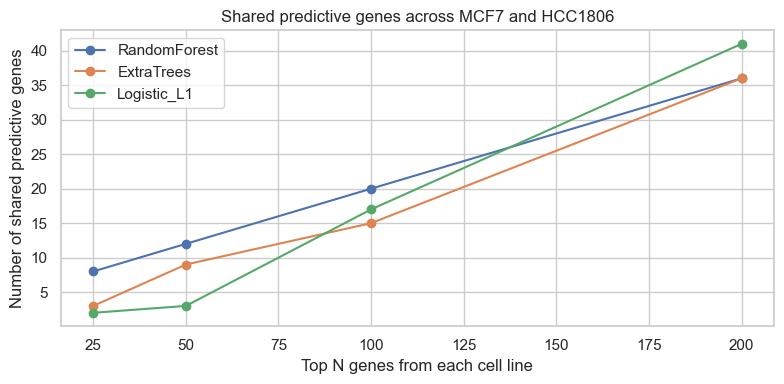

In [ ]:

# =============================================================
# Shared predictive genes across MCF7 and HCC1806: core signature
# =============================================================

def top_genes(cell_line, model="RandomForest", n=100):
    return set(annotated_rankings[cell_line][model].head(n)["gene"].str.upper())

core_rows = []
core_gene_tables = []
for model_name in MODELS:
    for n in [25, 50, 100, 200]:
        mcf7 = top_genes("MCF7", model_name, n)
        hcc = top_genes("HCC1806", model_name, n)
        shared = sorted(mcf7 & hcc)
        shared_hyp = sorted(set(shared) & {g.upper() for g in GENE_SETS["PDF_ALL_HYPOXIA_RELATED"]})
        core_rows.append({
            "model": model_name,
            "top_n": n,
            "MCF7_n": len(mcf7),
            "HCC1806_n": len(hcc),
            "shared_n": len(shared),
            "shared_hypoxia_related_n": len(shared_hyp),
            "shared_hypoxia_examples": ", ".join(shared_hyp[:15])
        })
        for g in shared:
            core_gene_tables.append({"model": model_name, "top_n": n, "gene": g, "hypoxia_related": g in {x.upper() for x in GENE_SETS["PDF_ALL_HYPOXIA_RELATED"]}})

core_summary = pd.DataFrame(core_rows)
core_genes_df = pd.DataFrame(core_gene_tables)
display(core_summary)
core_summary.to_csv(OUTPUT / "cross_cell_line_core_gene_summary.csv", index=False)
core_genes_df.to_csv(OUTPUT / "cross_cell_line_core_genes.csv", index=False)

# Visualize overlap size by model and top_n
plt.figure(figsize=(8, 4))
for model_name in MODELS:
    sub = core_summary[core_summary["model"] == model_name]
    plt.plot(sub["top_n"], sub["shared_n"], marker="o", label=model_name)
plt.xlabel("Top N genes from each cell line")
plt.ylabel("Number of shared predictive genes")
plt.title("Shared predictive genes across MCF7 and HCC1806")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# ======================================================
# Cross-cell-line generalization and combined-data models
# ======================================================

def align_train_test(X_train, X_test):
    common = sorted(set(X_train.columns) & set(X_test.columns))
    return X_train[common], X_test[common]

gen_rows = []
for model_name in MODELS:
    for train_line, test_line in [("MCF7", "HCC1806"), ("HCC1806", "MCF7")]:
        Xtr, ytr = loaded[train_line]["X"], loaded[train_line]["y"]
        Xte, yte = loaded[test_line]["X"], loaded[test_line]["y"]
        Xtr_a, Xte_a = align_train_test(Xtr, Xte)
        model = MODELS[model_name]
        model.fit(Xtr_a, ytr)
        pred = model.predict(Xte_a)
        proba = model.predict_proba(Xte_a)[:, 1] if hasattr(model, "predict_proba") else pred
        gen_rows.append({
            "model": model_name,
            "train_cell_line": train_line,
            "test_cell_line": test_line,
            "n_common_genes": Xtr_a.shape[1],
            "accuracy": accuracy_score(yte, pred),
            "f1": f1_score(yte, pred),
            "roc_auc": safe_auc(yte, proba),
        })

generalization_df = pd.DataFrame(gen_rows)
display(generalization_df)
generalization_df.to_csv(OUTPUT / "cross_cell_line_generalization.csv", index=False)

# Combined model across both cell lines
common_genes = sorted(set(loaded["MCF7"]["X"].columns) & set(loaded["HCC1806"]["X"].columns))
X_combined = pd.concat([
    loaded["MCF7"]["X"][common_genes].assign(cell_line_MCF7=1, cell_line_HCC1806=0),
    loaded["HCC1806"]["X"][common_genes].assign(cell_line_MCF7=0, cell_line_HCC1806=1),
], axis=0)
y_combined = np.concatenate([loaded["MCF7"]["y"], loaded["HCC1806"]["y"]])
cell_label = np.array(["MCF7"] * len(loaded["MCF7"]["y"]) + ["HCC1806"] * len(loaded["HCC1806"]["y"]))

combined_rows = []
for model_name in MODELS:
    Xtr, Xte, ytr, yte = train_test_split(X_combined, y_combined, test_size=0.25, random_state=42, stratify=y_combined)
    model = MODELS[model_name]
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else pred
    combined_rows.append({
        "model": model_name,
        "setting": "mixed random holdout",
        "accuracy": accuracy_score(yte, pred),
        "f1": f1_score(yte, pred),
        "roc_auc": safe_auc(yte, proba),
        "n_genes_plus_cell_line_features": X_combined.shape[1]
    })

combined_df = pd.DataFrame(combined_rows)
display(combined_df)
combined_df.to_csv(OUTPUT / "combined_cell_line_model.csv", index=False)


,model,train_cell_line,test_cell_line,n_common_genes,accuracy,f1,roc_auc
0,RandomForest,MCF7,HCC1806,1208,0.868132,0.860465,0.982353
1,RandomForest,HCC1806,MCF7,1208,0.964000,0.964981,0.996640
2,ExtraTrees,MCF7,HCC1806,1208,0.901099,0.901099,0.976471
3,ExtraTrees,HCC1806,MCF7,1208,0.956000,0.957529,0.998528
4,Logistic_L1,MCF7,HCC1806,1208,0.747253,0.701299,0.928199
5,Logistic_L1,HCC1806,MCF7,1208,0.960000,0.960938,0.998144


,model,setting,accuracy,f1,roc_auc,n_genes_plus_cell_line_features
0,RandomForest,mixed random holdout,0.990741,0.990826,0.997770,1210
1,ExtraTrees,mixed random holdout,0.990741,0.990826,0.999828,1210
2,Logistic_L1,mixed random holdout,0.981481,0.981481,0.999314,1210


## Final biological and coding interpretation of the completed results

The completed results show that the models are not only separating hypoxia from normoxia statistically, but are also recovering biologically meaningful hypoxia programs. In the holdout tests inside the professor-extension section, RandomForest and ExtraTrees reached perfect accuracy/F1/AUC for both MCF7 and HCC1806, while Logistic L1 was also extremely strong: perfect on MCF7 and 0.978 accuracy on HCC1806. This means the hypoxia label is highly learnable from the expression matrices.

The biological interpretation is strongest in HCC1806. For RandomForest, the top 25 HCC1806 genes already contained 16 hypoxia-related genes, increasing to 23 hits in the top 100. ExtraTrees gave a very similar pattern, with 15 hypoxia-related genes in the top 25 and 23 in the top 100. MCF7 also recovered hypoxia biology, but less strongly: RandomForest found 6 hypoxia-related genes in the top 25 and 13 in the top 100. This suggests that the hypoxia transcriptional signal is clearer or more concentrated in HCC1806 than in MCF7.

Several important genes are directly interpretable from hypoxia biology: BNIP3/BNIP3L relate to survival and apoptosis under hypoxic stress; ALDOA, HK2, LDHA, PGK1 and PFKFB3 are glycolysis-related; DDIT4, NDRG1, ERO1A, P4HA1 and EGLN3 are well-known hypoxia-response genes. The fact that these genes appear among the most important model features supports the professor's requested biological interpretation: the classifiers are learning a hypoxia response, not only memorizing arbitrary expression differences.

The ORA-style enrichment results support the same conclusion. In HCC1806 ExtraTrees top-100 genes, `PDF_ALL_HYPOXIA_RELATED` had 23 overlapping genes with an extremely small FDR (about 1.66e-27), and the compact hypoxia signature had 21 overlapping genes with FDR around 5.29e-26. Direct HIF targets and glycolysis were also strongly enriched. This matches the DataInterpretation PDF's recommendation to move from individual predictive genes to pathway/signature-level interpretation.

The cross-cell-line comparison also gives a useful result. RandomForest shared 8 genes between the MCF7 and HCC1806 top-25 lists, 20 genes in the top-100 lists, and 36 genes in the top-200 lists. Importantly, many shared genes were hypoxia-related: for RandomForest, 5 of the shared top-25 genes were hypoxia-related, and 11 of the shared top-100 genes were hypoxia-related. Examples include ALDOA, BNIP3, DDIT4, ERO1A, LDHA, NDRG1, P4HA1 and PGK1. This provides a small but meaningful core hypoxia signature across the two cell lines.

The cross-cell-line generalization experiment is especially important. Training on HCC1806 and testing on MCF7 generalized very well: RandomForest reached 0.964 accuracy and ExtraTrees reached 0.956 accuracy. Training on MCF7 and testing on HCC1806 was weaker but still good: RandomForest reached 0.868 accuracy and ExtraTrees reached 0.901 accuracy. Logistic L1 showed the largest asymmetry, dropping to 0.747 when trained on MCF7 and tested on HCC1806, while reaching 0.960 in the reverse direction. This suggests that HCC1806 contains a more transferable hypoxia signal, while MCF7 may contain a more cell-line-specific or weaker version of the response.

The combined-cell-line model was also strong. With both cell lines mixed, RandomForest and ExtraTrees reached 0.991 accuracy and Logistic L1 reached 0.981 accuracy. This means that a model trained across cell lines can still classify hypoxia very accurately, especially when cell-line indicator variables are included. However, because the mixed random holdout allows samples from both cell lines in train and test, this result should be interpreted together with the stricter cross-cell-line tests above.

From a coding perspective, the added analysis improves the notebook in four ways. First, every model now produces ranked gene-importance tables. Second, the ranked genes are automatically annotated against hypoxia/HIF gene sets from the professor's DataInterpretation PDF. Third, ORA enrichment is implemented directly in Python using a hypergeometric test and Benjamini-Hochberg correction, so the notebook can run without requiring internet access. Fourth, the generalization and combined-model code directly test whether the learned signal is cell-line-specific or shared.

Overall, the final conclusion is that hypoxia prediction works very well in both datasets, but the most scientifically useful result is not just high accuracy. The stronger result is that the models repeatedly select known hypoxia/HIF genes, recover glycolysis and hypoxia-response enrichment, identify a shared cross-cell-line core signature, and show that part of the signal generalizes between MCF7 and HCC1806.
